# PROJET UA 1 : Analyse des avis clients et développement d'assistants intelligents

## Contexte du mandat
L'Hôtel de la Promenade souhaite exploiter ses avis clients et sa documentation interne afin d'améliorer l'expérience client à l'aide de solutions d'intelligence artificielle. L'objectif est de transformer des données textuelles (avis) et des documents statiques en outils d'analyse et d'assistance.

## Objectifs principaux
1. Analyse et exploration des avis clients : extraire des thèmes récurrents, mesurer le sentiment et produire des insights exploitables.
2. Assistant RAG : répondre aux questions à partir de la documentation de l'hôtel en minimisant les hallucinations.
3. Assistant fine-tuné : adapter le style et le ton des réponses à l'identité de l'hôtel.

## Ressources disponibles
- Dataset d'avis : all_comments_ottawa.csv
- Documentation interne : politiques, FAQ, processus de réservations et autres documents fournis.

## Organisation du travail
Le projet est réalisé étape par étape, avec un notebook structuré par sections (importations, prétraitement, analyses thématiques, visualisations, puis RAG et fine-tuning).

# 1. Analyse et Exploration des Avis Clients

# Configuration

Préparation de l'environnement de calcul et lien a Google Drive.

In [18]:
import os
from google.colab import drive
import shutil
import random

drive.mount('/content/drive')

print(os.listdir("/content/drive/My Drive"))


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
['Colab Notebooks', '107 - Laboratoire 5.ipynb', 'Projet UA1 IAG']


In [19]:
import torch, torchvision
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
import numpy as np

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Utilisation de : {device}")

# Reproducibilité
def set_seed(seed: int = 42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed()

Utilisation de : cuda


## Chargement et inspection des données

Cette étape consiste à charger le jeu de données contenant les avis clients et à effectuer une première inspection afin de comprendre sa structure, sa taille et le type d’informations disponibles. Cette vérification permet de s’assurer que les données sont exploitables avant de commencer le prétraitement du texte.


In [20]:
import pandas as pd
import numpy as np

path = "/content/drive/MyDrive/Projet UA1 IAG/all_comments_ottawa.csv"

# Le CSV n'a pas d'en-tête, on force un nom de colonne
df = pd.read_csv(path, header=None, names=["critique"], encoding="utf-8")

print("Dimensions du dataset :", df.shape)
print("Colonnes :", list(df.columns))

df.head(10)

Dimensions du dataset : (5946, 1)
Colonnes : ['critique']


,critique
0,Chambre confortable mais décoration un peu dém...
1,Le spa propose un traitement signature exclusi...
2,Un séjour correct mais qui ne justifie pas ple...
3,The laundry service express saved our gala din...
4,L'exposition de collection d'art contemporain ...
5,L'emplacement privilégié est parfait pour expl...
6,Le petit-déjeuner buffet est varié et raffiné....
7,The staff is polite but seems to follow a rigi...
8,L’insonorisation entre les chambres est moyenn...
9,L'architecture du bâtiment est impressionnante...


Le fichier CSV contenant les avis clients ne possède pas d'en-tête de colonnes. Lors du chargement, une colonne nommée "critique" est donc créée afin de stocker l'ensemble des commentaires. Une inspection sera réalisée pour vérifier les dimensions du jeu de données, le type des variables et la présence de valeurs manquantes ainsi de suite.

In [21]:
# verification de la dimensions de mon dataset
df.shape


(5946, 1)

mes donnees comptent 5946 critiques au total.

In [22]:
df

,critique
0,Chambre confortable mais décoration un peu dém...
1,Le spa propose un traitement signature exclusi...
2,Un séjour correct mais qui ne justifie pas ple...
3,The laundry service express saved our gala din...
4,L'exposition de collection d'art contemporain ...
...,...
5941,Très bien situé (station de Vanier et autobus ...
5942,Très bon hôtel et très très bien situé. Les ch...
5943,Le plus important quand on est dans une ville ...
5944,Hotel De La Promenade est très bien situé et l...


In [23]:
# Vérification des types de colonnes
df.dtypes

,0
critique,object


In [24]:
# Vérification des valeurs manquantes
df.isna().sum()

,0
critique,0


## Identification automatique de la colonne texte

Sélectionner les colonnes de type texte ensuite calculer pour chaque colonne la longueur moyenne des chaînes de caractères ainsi que le ratio d’unicité (nombre de valeurs uniques / nombre de lignes échantillonnées) et enfin Classer les colonnes selon ces critères et sélectionner la plus pertinente comme colonne de texte principale.

In [25]:
# Heuristique pour identifier automatiquement la colonne texte
candidates = []

for col in df.columns:
    if df[col].dtype == "object":
        sample = df[col].dropna().astype(str).head(300)
        if len(sample) == 0:
            continue
        avg_len = sample.map(len).mean()
        uniq_ratio = sample.nunique() / len(sample)
        candidates.append((col, avg_len, uniq_ratio))

# Tri des colonnes candidates par longueur moyenne puis ratio d'unicité
candidates = sorted(candidates, key=lambda x: (x[1], x[2]), reverse=True)

# Affichage des meilleures candidates
print("Colonnes texte candidates (colonne, longueur_moyenne, ratio_unicite) :")
for c in candidates[:8]:
    print(c)

# Sélection de la colonne texte
if len(candidates) > 0:
    text_col = candidates[0][0]
    print("Colonne texte sélectionnée :", text_col)
else:
    raise ValueError("Aucune colonne texte valide n'a été trouvée dans le dataset.")

Colonnes texte candidates (colonne, longueur_moyenne, ratio_unicite) :
('critique', np.float64(137.85333333333332), 1.0)
Colonne texte sélectionnée : critique


## Nettoyage et normalisation du texte

Pour une etude sainte des texte, nous allons nettoyer et normaliser les avis clients afin de réduire le bruit présent dans les données textuelles. Les opérations appliquées incluent la mise en minuscules, la normalisation Unicode, l'harmonisation des apostrophes, la suppression des URLs et du code HTML éventuel, ainsi que l'élimination des caractères non pertinents. L'objectif est d'obtenir un texte propre et homogène, prêt pour les étapes de tokenisation, suppression des stopwords et lemmatisation.

In [26]:
import re
import unicodedata
import pandas as pd

def text_propre(text):
    # Gestion des valeurs manquantes
    if pd.isna(text):
        return ""

    # Conversion en string et minuscules
    text = str(text).lower()

    # Normalisation unicode
    text = unicodedata.normalize("NFKC", text)

    # Normaliser les apostrophes typographiques vers '
    text = text.replace("’", "'").replace("‘", "'").replace("`", "'")

    # Supprimer URLs et balises HTML si jamais
    text = re.sub(r"http\S+|www\S+", " ", text)
    text = re.sub(r"<.*?>", " ", text)

    # Garder lettres (avec accents), espaces et apostrophes
    text = re.sub(r"[^a-zà-ÿ\s']", " ", text)

    # Supprimer espaces multiples
    text = re.sub(r"\s+", " ", text).strip()

    return text

## Application au dataset
apres avoir elaborer les critere et techniques de nettoyage je l'applique au dataset

In [27]:
# Application du nettoyage à la colonne texte
df["critique_propre"] = df["critique"].apply(text_propre)

# Aperçu comparatif
df[["critique", "critique_propre"]].head(10)

,critique,critique_propre
0,Chambre confortable mais décoration un peu dém...,chambre confortable mais décoration un peu dém...
1,Le spa propose un traitement signature exclusi...,le spa propose un traitement signature exclusi...
2,Un séjour correct mais qui ne justifie pas ple...,un séjour correct mais qui ne justifie pas ple...
3,The laundry service express saved our gala din...,the laundry service express saved our gala din...
4,L'exposition de collection d'art contemporain ...,l'exposition de collection d'art contemporain ...
5,L'emplacement privilégié est parfait pour expl...,l'emplacement privilégié est parfait pour expl...
6,Le petit-déjeuner buffet est varié et raffiné....,le petit déjeuner buffet est varié et raffiné ...
7,The staff is polite but seems to follow a rigi...,the staff is polite but seems to follow a rigi...
8,L’insonorisation entre les chambres est moyenn...,l'insonorisation entre les chambres est moyenn...
9,L'architecture du bâtiment est impressionnante...,l'architecture du bâtiment est impressionnante...


##  Analyse de la langue du corpus

In [14]:
import spacy
import pandas as pd

# Détection des langues presentent dans le corpus
!pip -q install langdetect
from langdetect import detect, LangDetectException

def detect_lang(text):
    try:
        if not text or len(text) < 10:
            return "unknown"
        return detect(text)  # renvoie souvent 'fr' ou 'en'
    except LangDetectException:
        return "unknown"

df["lang"] = df["critique_propre"].apply(detect_lang)
df["lang"].value_counts().head(10)

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 981.5/981.5 kB 64.5 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done


,count
lang,
en,5032
fr,912
it,1
es,1


Le corpus d'avis clients est composé majoritairement de textes en anglais, avec une proportion plus réduite d'avis en français. Une très faible quantité d'avis dans d'autres langues (italien et espagnol) est également présente.

La répartition observée est la suivante :
- Anglais : majorité des avis
- Français : minorité significative
- Autres langues : cas isolés

Afin de garantir une analyse cohérente et statistiquement pertinente, seules les langues anglaise et française sont conservées pour la suite du traitement. Les langues très peu représentées sont exclues, car elles n'ont pas d'impact significatif sur l'analyse thématique globale.

In [15]:
# On conserve uniquement les avis en anglais et en français
df_filtre = df[df["lang"].isin(["en", "fr"])].copy()

print("Répartition des langues après filtrage :")
print(df_filtre["lang"].value_counts())

Répartition des langues après filtrage :
lang
en    5032
fr     912
Name: count, dtype: int64


La détection et le filtrage de la langue sont effectués avant la tokenisation afin d'appliquer des règles linguistiques adaptées (stopwords et lemmatisation) et d'éviter l'introduction de bruit dû au mélange de langues très peu représentées.

## Tokenisation et suppression des stopwords

Après le nettoyage, le texte doit être découpé en token afin de pouvoir réaliser des analyses statistiques (fréquences, n-grammes, TF-IDF) et préparer les étapes de lemmatisation et d’analyse thématique.  
Ensuite, on supprime les stopwords (mots très fréquents comme "le", "de", "and", "the") car ils apportent peu d'information sur le contenu réel des avis et peuvent masquer les thèmes importants.

le corpus contient des avis en français et en anglais. Pour cette raison, on utilise deux modèles spaCy (français et anglais) et une détection de langue afin d'appliquer les stopwords et la tokenisation adaptés à chaque texte.

In [16]:
!pip -q install spacy
!python -m spacy download fr_core_news_sm
!python -m spacy download en_core_web_sm

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.3/16.3 MB 26.4 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('fr_core_news_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 59.2 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.


In [17]:
import spacy

nlp_fr = spacy.load("fr_core_news_sm")
nlp_en = spacy.load("en_core_web_sm")

# Tokenisation + suppression stopwords + filtrage de tokens non pertinents
def tokenizer_spacy(text, lang):
    if pd.isna(text) or text.strip() == "":
        return []

    # Choix du bon modèle spaCy
    nlp = nlp_fr if lang == "fr" else nlp_en if lang == "en" else None

    # Fallback si langue inconnue
    if nlp is None:
        return [t for t in text.split() if len(t) > 2 and t.isalpha()]

    doc = nlp(text)

    tokens = [
        token.text
        for token in doc
        if token.is_alpha            # garder uniquement des mots
        and not token.is_stop        # retirer stopwords
        and len(token.text) > 2      # retirer tokens trop courts
    ]
    return tokens
# Application sur le dataset filtré (anglais + français)

df_filtre["tokens"] = [tokenizer_spacy(t, l) for t, l in zip(df_filtre["critique_propre"], df_filtre["lang"])]
df_filtre[["critique_propre", "lang", "tokens"]].head(10)

,critique_propre,lang,tokens
0,chambre confortable mais décoration un peu dém...,fr,"[chambre, confortable, décoration, démodée, pe..."
1,le spa propose un traitement signature exclusi...,fr,"[spa, propose, traitement, signature, exclusif..."
2,un séjour correct mais qui ne justifie pas ple...,fr,"[séjour, correct, justifie, pleinement, classe..."
3,the laundry service express saved our gala din...,en,"[laundry, service, express, saved, gala, dinne..."
4,l'exposition de collection d'art contemporain ...,fr,"[exposition, collection, art, contemporain, hô..."
5,l'emplacement privilégié est parfait pour expl...,fr,"[emplacement, privilégié, parfait, explorer, v..."
6,le petit déjeuner buffet est varié et raffiné ...,fr,"[petit, déjeuner, buffet, varié, raffiné, réap..."
7,the staff is polite but seems to follow a rigi...,en,"[staff, polite, follow, rigid, protocol, offer..."
8,l'insonorisation entre les chambres est moyenn...,fr,"[insonorisation, chambres, moyenne, promesses,..."
9,l'architecture du bâtiment est impressionnante...,fr,"[architecture, bâtiment, impressionnante, domm..."


Après le nettoyage et la normalisation, les avis sont découpés en tokens. Cette étape permet de transformer chaque avis en une liste de mots exploitables pour les analyses statistiques (fréquences, n-grammes, TF-IDF) et pour la lemmatisation.

La suppression des stopwords est appliquée afin de réduire le bruit et de faire ressortir les termes réellement informatifs. Comme le corpus est bilingue (anglais et français), deux modèles spaCy sont utilisés et le modèle est sélectionné en fonction de la langue détectée pour chaque avis.

## Lemmatisation des tokens

Cette étape me permetra de réduire la variabilité lexicale et d'améliorer la qualité des analyses statistiques et thématiques, en regroupant sous une même forme les variantes morphologiques d'un même mot.


In [18]:
def lemmatise_tokens(tokens, lang):
    if tokens is None or len(tokens) == 0:
        return []

    # Choix du modèle selon la langue
    nlp = nlp_fr if lang == "fr" else nlp_en if lang == "en" else None

    # Fallback simple si langue inconnue
    if nlp is None:
        return tokens

    doc = nlp(" ".join(tokens))

    lemmas = [
        token.lemma_
        for token in doc
        if token.is_alpha
        and not token.is_stop
        and len(token.text) > 2
    ]
    return lemmas

In [19]:
print(df_filtre.columns)

Index(['critique', 'critique_propre', 'lang', 'tokens'], dtype='object')


In [20]:
# Application de la lemmatisation sur le dataset filtré
df_filtre["lemmas"] = [
    lemmatise_tokens(tok, l) for tok, l in zip(df_filtre["tokens"], df_filtre["lang"])
]

# Aperçu comparatif
df_filtre[["tokens", "lemmas"]].head(10)

,tokens,lemmas
0,"[chambre, confortable, décoration, démodée, pe...","[chambre, confortable, décoration, démoder, pe..."
1,"[spa, propose, traitement, signature, exclusif...","[spa, proposer, traitement, signatur, exclusif..."
2,"[séjour, correct, justifie, pleinement, classe...","[séjour, correct, justifi, pleinement, classem..."
3,"[laundry, service, express, saved, gala, dinne...","[laundry, service, express, save, gala, dinner..."
4,"[exposition, collection, art, contemporain, hô...","[exposition, collection, art, contemporain, hô..."
5,"[emplacement, privilégié, parfait, explorer, v...","[emplacement, privilégier, parfaire, explorer,..."
6,"[petit, déjeuner, buffet, varié, raffiné, réap...","[petit, déjeuner, buffet, varier, raffiner, ré..."
7,"[staff, polite, follow, rigid, protocol, offer...","[staff, polite, follow, rigid, protocol, offer..."
8,"[insonorisation, chambres, moyenne, promesses,...","[insonorisation, chambre, moyen, promesse, tra..."
9,"[architecture, bâtiment, impressionnante, domm...","[architecture, bâtiment, impressionnant, domma..."


## Analyse des fréquences de lemmes

Cette étape permet d'identifier les termes les plus utilisés par les clients et d'obtenir une première vue d'ensemble des sujets dominants dans les avis.


In [21]:
from collections import Counter
import pandas as pd

# Aplatir la liste des lemmes
all_lemmas = [lemma for lemmas in df_filtre["lemmas"] for lemma in lemmas]

# Filtrage de sécurité
all_lemmas = [w for w in all_lemmas if w.isalpha() and len(w) > 2]

# Comptage des fréquences
lemma_freq = Counter(all_lemmas)

# Affichage des 20 lemmes les plus fréquents
lemma_freq.most_common(20)

[('hotel', 15159),
 ('room', 11871),
 ('stay', 6257),
 ('promenade', 5549),
 ('ottawa', 4334),
 ('staff', 3072),
 ('great', 2987),
 ('good', 2875),
 ('service', 2771),
 ('night', 2565),
 ('location', 2386),
 ('time', 2242),
 ('check', 2152),
 ('bed', 2032),
 ('small', 1812),
 ('lobby', 1809),
 ('clean', 1805),
 ('day', 1719),
 ('bathroom', 1715),
 ('nice', 1707)]

En plus des stopwords standards, certains termes très génériques liés au contexte de l’hôtel (comme "hotel", "room", "chambre", "séjour" etc ...) ont été exclus par la suite afin de faire ressortir des thèmes plus informatifs pour l’analyse.

In [22]:
# Liste de mots génériques à exclure
stop_extra = {
    "hotel", "room", "stay", "staff", "promenade", "ottawa",
    "chambre", "hôtel", "séjour", "personnel"
}

# Filtrage des lemmes génériques
filtered_lemmas = [w for w in all_lemmas if w not in stop_extra]

freq_filtre = Counter(filtered_lemmas)

# Transformation en DataFrame pour visualisation
top_words = pd.DataFrame(freq_filtre.most_common(15), columns=["mot", "frequence"])
top_words

,mot,frequence
0,great,2987
1,good,2875
2,service,2771
3,night,2565
4,location,2386
5,time,2242
6,check,2152
7,bed,2032
8,small,1812
9,lobby,1809


##Visualisation

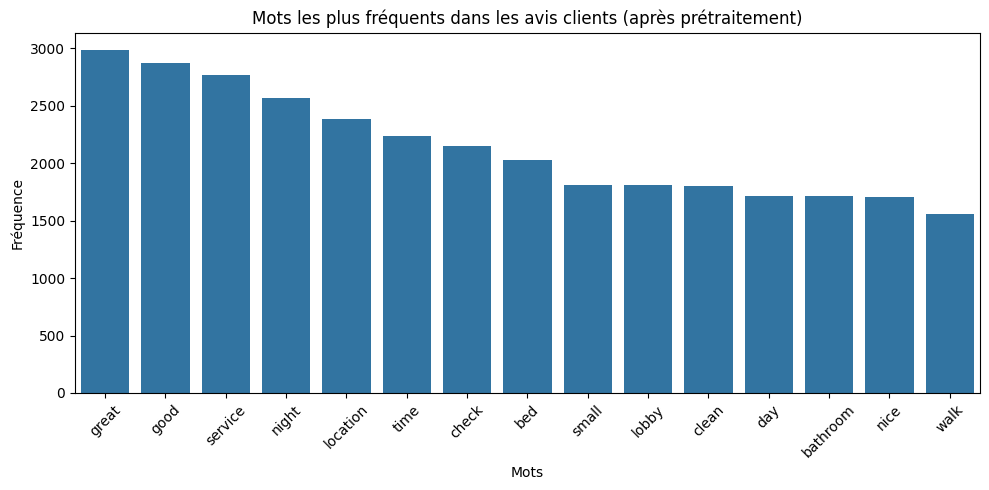

In [23]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 5))
sns.barplot(data=top_words, x="mot", y="frequence")
plt.title("Mots les plus fréquents dans les avis clients (après prétraitement)")
plt.xlabel("Mots")
plt.ylabel("Fréquence")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

afin de faire ressortir des thèmes plus spécifiques liés aux services, au confort et à la propreté je vais encore filtrer certains mots basiques pour une meilleurs analse


In [24]:
stop_extra_1 = {
    # Contexte hôtel
    "hotel", "room", "stay", "staff", "promenade", "ottawa",
    "chambre", "hôtel", "séjour", "personnel",

    # Jugements vagues
    "good", "great", "nice", "excellent", "well", "bad", "poor",
    "bon", "bien", "très", "super", "excellent", "agréable",

    # Mots génériques d'expérience
    "place", "time", "night", "day", "trip", "visit", "experience",
    "endroit", "fois", "jour", "nuit", "voyage", "expérience",

    # Intensificateurs / bruit
    "very", "really", "quite", "too",
    "peu", "trop", "beaucoup",

    # Verbes génériques
    "be", "have", "do", "get", "go", "make", "take", "use",
    "être", "avoir", "faire", "aller", "prendre", "mettre", "donner",

    # Méta-avis
    "recommend", "review", "would", "will",
    "recommande", "avis", "voudrais"
}


# Filtrage des lemmes génériques
filtered_lemmas_1 = [w for w in all_lemmas if w not in stop_extra_1]

freq_filtre_1 = Counter(filtered_lemmas_1)

# Transformation en DataFrame pour visualisation
top_words_1 = pd.DataFrame(freq_filtre_1.most_common(15), columns=["mot", "frequence"])
top_words_1

,mot,frequence
0,service,2771
1,location,2386
2,check,2152
3,bed,2032
4,small,1812
5,lobby,1809
6,clean,1805
7,bathroom,1715
8,walk,1557
9,parliament,1450


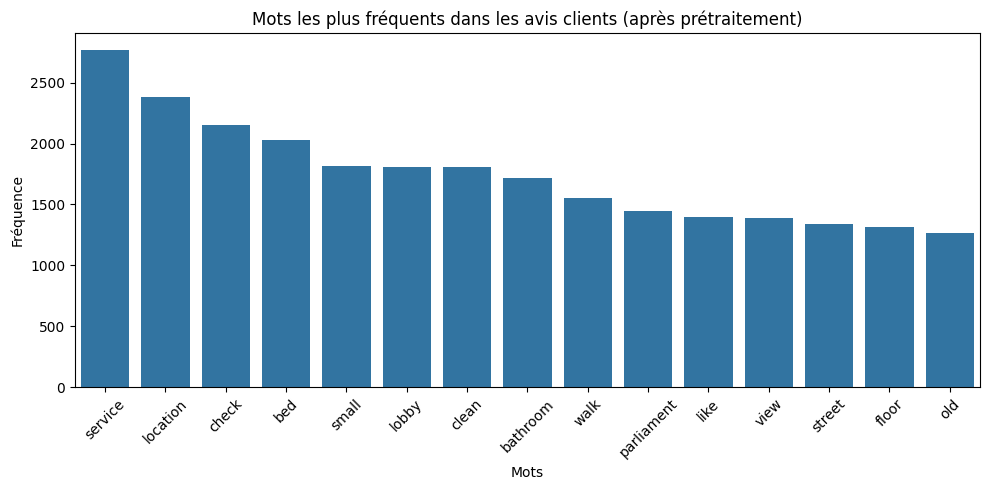

In [25]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 5))
sns.barplot(data=top_words_1, x="mot", y="frequence")
plt.title("Mots les plus fréquents dans les avis clients (après prétraitement)")
plt.xlabel("Mots")
plt.ylabel("Fréquence")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Après le premier filtrage des mots trop génériques, une seconde analyse des fréquences met en évidence des termes directement liés aux dimensions clés de l’expérience client : le service, la localisation, la propreté, le confort des chambres (lit, salle de bain, taille, état), ainsi que l’environnement et les espaces communs. Ces résultats confirment que les avis clients se structurent principalement autour de ces grands axes thématiques.

## Visualisation des thèmes – Nuage de mots (WordCloud)

Après le filtrage des termes trop génériques, un nuage de mots est généré à partir des lemmes restants afin de visualiser rapidement les thèmes dominants présents dans les avis clients. La taille de chaque mot est proportionnelle à sa fréquence d’apparition dans le corpus. Cette visualisation permet d’identifier visuellement les sujets les plus discutés, tels que le service, la localisation, la propreté ou encore le confort des chambres.

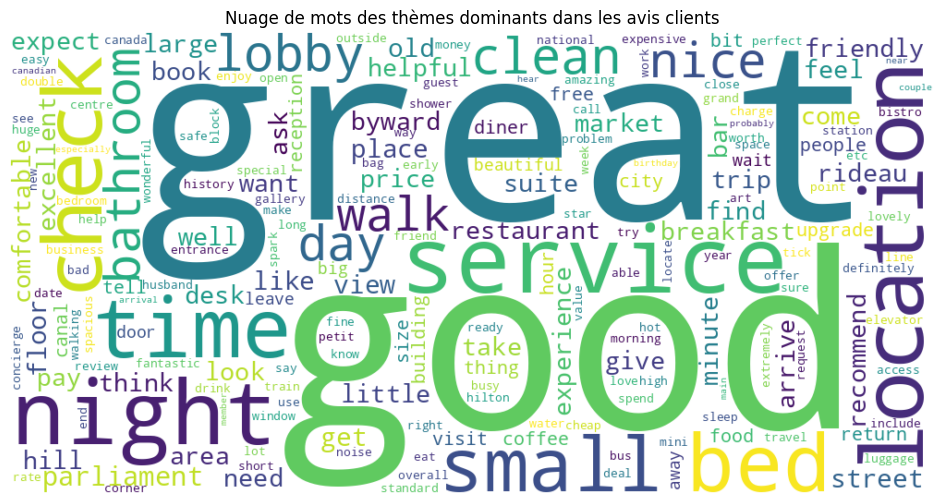

In [26]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

# Création du WordCloud à partir des fréquences filtrées
wordcloud = WordCloud(
    width=1000,
    height=500,
    background_color="white",
    colormap="viridis"
).generate_from_frequencies(freq_filtre)

# Affichage
plt.figure(figsize=(12, 6))
plt.imshow(wordcloud, interpolation="bilinear")
plt.axis("off")
plt.title("Nuage de mots des thèmes dominants dans les avis clients")
plt.show()

Le nuage de mots met en évidence les thèmes dominants des avis clients, notamment le service, la localisation, la propreté et le confort des chambres. Cette visualisation confirme les résultats de l’analyse fréquentielle et permet d’identifier rapidement les dimensions clés de l’expérience client à l’Hôtel de la Promenade.

## interpretation

D’un point de vue global, on remarque immédiatement que le mot “great” est le plus dominant. Cela suggère que, dans l’ensemble, les clients ont une perception très positive de leur séjour.
On voit aussi des mots comme “good”, “nice”, “clean”, “comfortable”, “friendly” et “helpful”, qui renforcent l’idée que l’expérience client est majoritairement satisfaisante.
Même si le nuage ne montre pas directement un pourcentage de satisfaction, la forte présence de mots positifs permet de conclure que les avis sont globalement bons.


en observant location, cela pourrai indique que l’emplacement de l’hôtel est un élément aborde dans les commentaires car on observe aussi des mots comme “Parliament”,“rideau”. Cela suggère que l’hôtel est bien situé, probablement proche de lieux touristiques importants. par la suite certains mots qui touche a la qualite des chambres et du peronnel.Même si ces mots sont moins dominants que “great” ou “location”, ils montrent que les clients évaluent plusieurs aspects de leur séjour



## Distribution des sentiments (bilingue) — classification + gestion de l’incertitude

### Objectif
Cette étape vise à **mesurer la répartition des avis** (positif / neutre / négatif) à partir de la colonne de texte nettoyé critique_propre

Comme les avis sont parfois ambigus (ex: c’était correct), on applique une règle simple : **si le modèle n’est pas assez confiant, on classe en “neutre”**.

### Pourquoi ajouter une règle “neutre si incertain” ?
pour eviter que le modèle de sentiments renvoie toujours une classe gagnante, même quand le texte est mitigé et pour éviter de forcer un avis dans positifnégatif, on considère **neutre** si :
- le meilleur score est trop faible (**top_score < 0.60**)  
**ou**
- l’écart entre la meilleure et la deuxième meilleure classe est faible (**top1 - top2 < 0.10**)

Cela rend la distribution plus réaliste pour des retours clients nuancés.


### Résultat attendu
- Une nouvelle colonne sentiment_final (positive / neutral / negative)
- Un graphique montrant la proportion de chaque sentiment
- Une justification claire : le neutre capture les avis ambivalents lorsque le modèle manque de certitude

In [13]:
import os
import torch
from transformers import AutoTokenizer, AutoModelForSequenceClassification, pipeline

# (Optionnel) évite certains imports vision inutiles
os.environ["TRANSFORMERS_NO_TORCHVISION"] = "1"

MODEL_SENTIMENT = "cardiffnlp/twitter-xlm-roberta-base-sentiment"
LABEL_MAP = {"LABEL_0": "negative", "LABEL_1": "neutral", "LABEL_2": "positive"}

device = 0 if torch.cuda.is_available() else -1
print("Device:", "GPU" if device == 0 else "CPU")

# Charger tokenizer + modèle explicitement (plus stable)
tokenizer = AutoTokenizer.from_pretrained(MODEL_SENTIMENT)
model = AutoModelForSequenceClassification.from_pretrained(MODEL_SENTIMENT)

# Pipeline
sentiment_pipe = pipeline(
    task="text-classification",
    model=model,
    tokenizer=tokenizer,
    device=device
)

import torch

def predict_sentiment_with_neutral(text: str, thr_top=0.60, thr_gap=0.10, max_len=256):
    # 1) Tokenize (force truncation)
    inputs = tokenizer(
        text,
        return_tensors="pt",
        truncation=True,
        max_length=max_len,
        padding=True
    )

    # 2) Put on correct device
    if device == 0:
        inputs = {k: v.cuda() for k, v in inputs.items()}
        model.cuda()
    else:
        model.cpu()

    # 3) Forward -> logits -> softmax scores for all labels
    with torch.no_grad():
        out = model(**inputs)
        probs = torch.softmax(out.logits, dim=-1)[0].detach().cpu().numpy()

    # 4) Build scores list like pipeline would
    scores = []
    for i, p in enumerate(probs):
        lab = model.config.id2label[i]  # ex: LABEL_0
        scores.append({"label": lab, "score": float(p)})

    scores_sorted = sorted(scores, key=lambda d: d["score"], reverse=True)
    top1, top2 = scores_sorted[0], scores_sorted[1]
    top1_score = top1["score"]
    gap = top1["score"] - top2["score"]

    # 5) Uncertainty -> neutral
    if (top1_score < thr_top) or (gap < thr_gap):
        return "neutral", top1_score, gap, scores_sorted
    else:
        return LABEL_MAP.get(top1["label"], top1["label"]), top1_score, gap, scores_sorted

# Test rapide
tests = [
    "Service excellent, chambre très propre.",
    "C'était correct, rien d'exceptionnel.",
    "Très déçu, bruit et accueil froid."
]

for t in tests:
    lab, top, gap, _ = predict_sentiment_with_neutral(t)
    print(f"{t}\n -> {lab} | top={top:.3f} | gap={gap:.3f}\n")

Device: GPU


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

XLMRobertaForSequenceClassification LOAD REPORT from: cardiffnlp/twitter-xlm-roberta-base-sentiment
Key                             | Status     |  | 
--------------------------------+------------+--+-
roberta.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Service excellent, chambre très propre.
 -> positive | top=0.910 | gap=0.841

C'était correct, rien d'exceptionnel.
 -> neutral | top=0.528 | gap=0.287

Très déçu, bruit et accueil froid.
 -> negative | top=0.963 | gap=0.938



vu les resultats de mon test je peux accorder une confiance au model et appliquer la classification sur l'ensemble de mes donnees

In [14]:
# Appliquer la prédiction à tout le dataset

import pandas as pd

sample_df = df.copy()

# applique la fonction sur toute la colonne
preds = sample_df["critique_propre"].astype(str).apply(predict_sentiment_with_neutral)

# preds renvoie (label_final, top1_score, gap, scores_sorted)
sample_df["sentiment_final"] = preds.apply(lambda x: x[0])
sample_df["sentiment_top_score"] = preds.apply(lambda x: float(x[1]))
sample_df["sentiment_gap"] = preds.apply(lambda x: float(x[2]))

#  Distribution (comptes + pourcentages) ---
dist_counts = sample_df["sentiment_final"].value_counts()
dist_pct = sample_df["sentiment_final"].value_counts(normalize=True).mul(100).round(2)

print("Distribution (comptes):")
print(dist_counts)
print("\nDistribution (%):")
print(dist_pct)


uncertain = sample_df[
    (sample_df["sentiment_top_score"] < 0.60) | (sample_df["sentiment_gap"] < 0.10)
].head(10)[["critique_propre", "sentiment_final", "sentiment_top_score", "sentiment_gap"]]

print("\nExemples classés neutre par incertitude (aperçu):")
print(uncertain.to_string(index=False))

Distribution (comptes):
sentiment_final
neutral     3718
positive    1537
negative     691
Name: count, dtype: int64

Distribution (%):
sentiment_final
neutral     62.53
positive    25.85
negative    11.62
Name: proportion, dtype: float64

Exemples classés neutre par incertitude (aperçu):
                                                                                                                                                           critique_propre sentiment_final  sentiment_top_score  sentiment_gap
                 un séjour correct mais qui ne justifie pas pleinement son classement luxe service professionnel mais sans cette touche personnelle qui fait la différence         neutral             0.502449       0.193542
                                                                                        the laundry service express saved our gala dinner following a last minute incident         neutral             0.443415       0.157434
                l'expérience nologique da

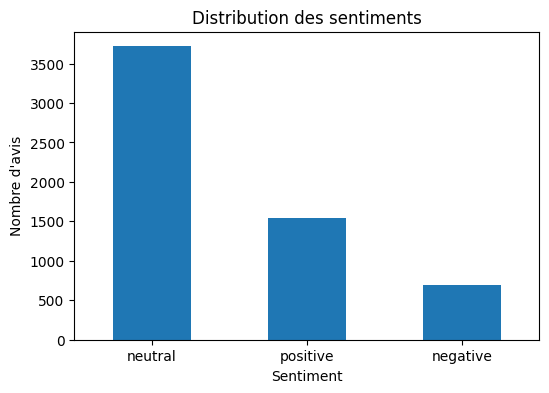

In [15]:
import matplotlib.pyplot as plt

dist_counts = sample_df["sentiment_final"].value_counts()

plt.figure(figsize=(6,4))
dist_counts.plot(kind="bar")
plt.title("Distribution des sentiments")
plt.xlabel("Sentiment")
plt.ylabel("Nombre d'avis")
plt.xticks(rotation=0)
plt.show()

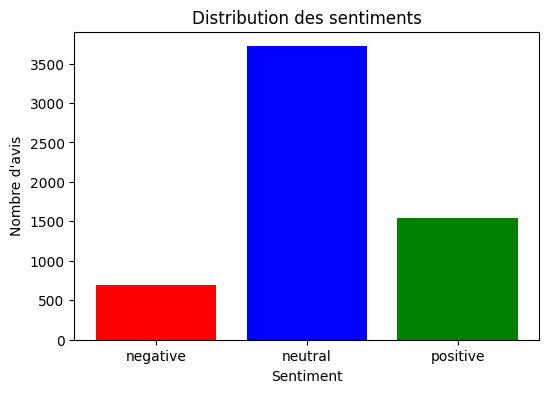

In [17]:
# Graphique distribution avec couleurs et classement
import matplotlib.pyplot as plt

order = ["negative", "neutral", "positive"]
colors = {"negative": "red", "neutral": "blue", "positive": "green"}

dist_counts = sample_df["sentiment_final"].value_counts().reindex(order).fillna(0)

plt.figure(figsize=(6,4))
plt.bar(dist_counts.index, dist_counts.values, color=[colors[s] for s in dist_counts.index])
plt.title("Distribution des sentiments")
plt.xlabel("Sentiment")
plt.ylabel("Nombre d'avis")
plt.xticks(rotation=0)
plt.show()

##Interprétation de la distribution des sentiments

Sur l’ensemble des avis analysés, la majorité est classée “neutre” : 3718 avis (62,53%). Les avis positifs représentent 1537 avis (25,85%), tandis que les négatifs sont 691 avis (11,62%).

Cette distribution suggère que, globalement, l’expérience décrite par les clients est plutôt stable et sans polarisation forte : beaucoup d’avis expriment des impressions mitigées (“correct mais…”, “bien mais pas exceptionnel”), ou bien contiennent un vocabulaire valorisant sans exprimer une satisfaction émotionnelle très nette.

Pourquoi autant de neutres ?
Ici, une partie des neutres provient du filtre d’incertitude que nous avons ajouté donc une bonne fraction des avis neutres sont en réalité des avis ambigus, nuancés, ou difficiles à trancher

les avis sont très souvent nuancés ou formulés de manière descriptive, ce qui rend la polarité pure (positif/négatif) moins dominante.

### Neutres natifs vs neutres incertitude

Dans cette analyse, la classe **neutre** peut provenir de deux mécanismes distincts :

1. **Neutre natif (prédiction du modèle)** : le modèle classe directement l’avis comme *neutral* et la prédiction est jugée suffisamment stable.
2. **Neutre par incertitude (règles)** : l’avis est forcé en *neutral* lorsque la prédiction est jugée trop incertaine, selon les seuils :
   - **top score < 0,60** (confiance trop faible)
   - ou **top1 − top2 < 0,10** (hésitation entre deux classes)

Cette séparation permet d’éviter de forcer une polarité (positif/négatif) lorsque le modèle hésite fortement, et donne une lecture plus réaliste des avis ambigus ou nuancés.

In [28]:
import numpy as np

# Paramètres règles
TOP_MIN = 0.60
GAP_MIN = 0.10

df_eval = sample_df.copy()

# Détecter quels neutres viennent des règles d'incertitude
df_eval["forced_neutral"] = (df_eval["sentiment_top_score"] < TOP_MIN) | (df_eval["sentiment_gap"] < GAP_MIN)

#  Catégories finales
# - neutral_forced : final neutral ET forced_neutral True
# - neutral_native : final neutral ET forced_neutral False
df_eval["neutral_type"] = np.where(
    (df_eval["sentiment_final"] == "neutral") & (df_eval["forced_neutral"]),
    "neutral_forced",
    np.where(
        (df_eval["sentiment_final"] == "neutral") & (~df_eval["forced_neutral"]),
        "neutral_native",
        "not_neutral"
    )
)

# Comptes / %
total = len(df_eval)
counts = df_eval["neutral_type"].value_counts()

neutral_forced_n = int(counts.get("neutral_forced", 0))
neutral_native_n = int(counts.get("neutral_native", 0))
neutral_total_n  = neutral_forced_n + neutral_native_n

# % sur tout le dataset
pct_forced_all = 100 * neutral_forced_n / total
pct_native_all = 100 * neutral_native_n / total
pct_neutral_all = 100 * neutral_total_n / total

# % parmi les neutres seulement
pct_forced_within_neutral = 100 * neutral_forced_n / neutral_total_n if neutral_total_n else 0
pct_native_within_neutral = 100 * neutral_native_n / neutral_total_n if neutral_total_n else 0

print("=== Neutres natifs vs neutres par incertitude ===")
print(f"Total avis : {total}")

print("\n--- Sur l'ensemble des avis ---")
print(f"Neutres (total)        : {neutral_total_n} ({pct_neutral_all:.2f}%)")
print(f"Neutres NATIFS         : {neutral_native_n} ({pct_native_all:.2f}%)")
print(f"Neutres INCERTITUDE    : {neutral_forced_n} ({pct_forced_all:.2f}%)")

print("\n--- Parmi les neutres seulement ---")
print(f"Part neutres NATIFS      : {pct_native_within_neutral:.2f}%")
print(f"Part neutres INCERTITUDE : {pct_forced_within_neutral:.2f}%")

#  aperçu des neutres forcés les plus "incertains"
display_cols = ["critique_propre", "sentiment_final", "sentiment_top_score", "sentiment_gap"]
print("\nAperçu neutres INCERTITUDE (10 exemples):")
display(df_eval[df_eval["neutral_type"]=="neutral_forced"][display_cols].head(10))

=== Neutres natifs vs neutres par incertitude ===
Total avis : 5946

--- Sur l'ensemble des avis ---
Neutres (total)        : 3718 (62.53%)
Neutres NATIFS         : 24 (0.40%)
Neutres INCERTITUDE    : 3694 (62.13%)

--- Parmi les neutres seulement ---
Part neutres NATIFS      : 0.65%
Part neutres INCERTITUDE : 99.35%

Aperçu neutres INCERTITUDE (10 exemples):


,critique_propre,sentiment_final,sentiment_top_score,sentiment_gap
2,un séjour correct mais qui ne justifie pas ple...,neutral,0.502449,0.193542
3,the laundry service express saved our gala din...,neutral,0.443415,0.157434
12,l'expérience nologique dans la cave secrète av...,neutral,0.413740,0.008898
14,the ballroom with historical significance wher...,neutral,0.455661,0.005371
18,the celebrated chef has created an exclusive m...,neutral,0.524657,0.094807
19,the concierge service arranged a private eveni...,neutral,0.483115,0.070205
26,hotel de la promenade offers private cultural ...,neutral,0.539489,0.153188
31,the breakfast was a royal feast with homemade ...,neutral,0.501460,0.047397
34,the wellness program offers personalized sessi...,neutral,0.548235,0.112152
36,chambre confortable mais plus petite que suggé...,neutral,0.428879,0.049796


###Interprétation

Sur 5 946 avis, la classe neutral représente 62,53%. Cependant, cette neutralité provient presque entièrement de la règle d’incertitude ajoutée après prédiction : seuls 24 avis (0,40% du total) sont des neutres *natifs* du modèle, alors que 3 694 avis (62,13% du total) sont des neutres *forcés* par les seuils d’incertitude.
Autrement dit, parmi les avis classés neutres, 99,35% sont des neutres incertitude et seulement 0,65% des neutres réels.

Cela est du au fait que beaucoup des avis décrivent surtout une scène ou un service (sans dire clairement j’ai adoré ou j’ai détesté), et plusieurs sont nuancés avec du positif + une réserve, donc le modèle hésite. En plus, le modèle utilises est entraîné sur des tweets. Comme les seuils fixes sont assez stricts, dès que la confiance est moyenne ou que deux sentiments se rapprochent, je classes automatiquement ces cas en neutre, d’où le gros pourcentage.

##  Analyse des n-grammes (bigrams et trigrams)

Après l’analyse des mots isolés, l’étude des n-grammes me permetra d’identifier les expressions les plus fréquentes dans les avis clients. Cette analyse permetra de mieux comprendre comment les clients formulent leurs opinions et quels aspects précis de l’hôtel sont le plus souvent mentionnés.

In [ ]:
from sklearn.feature_extraction.text import CountVectorizer

#reconstruit un texte par avis à partir des lemmes
texts_for_ngrams = df_filtre["lemmas"].apply(lambda x: " ".join(x))

texts_for_ngrams.head()

,lemmas
0,chambre confortable décoration démoder petit d...
1,spa proposer traitement signatur exclusif déve...
2,séjour correct justifi pleinement classemer lu...
3,laundry service express save gala dinner follo...
4,exposition collection art contemporain hôtel p...


bigrams

In [ ]:
# Vectorizer pour bigrams
vectorizer_bi = CountVectorizer(ngram_range=(2, 2), min_df=10)
X_bi = vectorizer_bi.fit_transform(texts_for_ngrams)

# Fréquences
bi_freq = np.array(X_bi.sum(axis=0)).flatten()
bi_vocab = np.array(vectorizer_bi.get_feature_names_out())

# DataFrame des bigrams les plus fréquents
df_bi = pd.DataFrame({"bigram": bi_vocab, "frequence": bi_freq})
df_bi = df_bi.sort_values(by="frequence", ascending=False).head(30)

df_bi

,bigram,frequence
1417,hotel promenade,5420
2933,stay hotel,1770
326,byward market,954
2070,parliament hill,905
2435,rideau canal,671
2608,room small,611
2603,room service,533
2069,parliament building,463
1148,great location,418
2484,room clean,416


visualisation

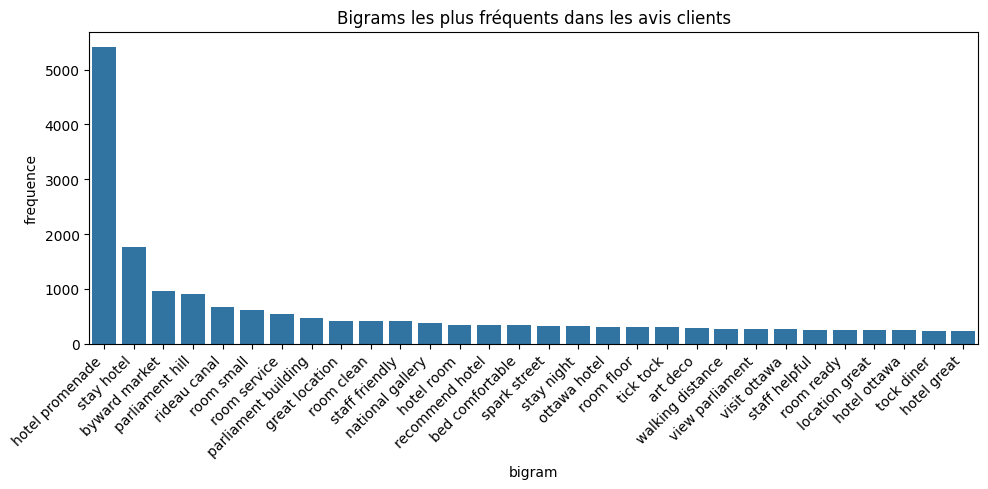

In [ ]:
plt.figure(figsize=(10, 5))
sns.barplot(data=df_bi, x="bigram", y="frequence")
plt.title("Bigrams les plus fréquents dans les avis clients")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

L’analyse des bigrams met en évidence des expressions récurrentes décrivant précisément l’expérience client. On observe notamment des groupes de mots liés à la localisation et aux attractions touristiques (Byward Market, Parliament Hill, Rideau Canal), au confort des chambres (room clean, room small, bed comfortable), ainsi qu’à la qualité du personnel (staff friendly, staff helpful). Ces résultats confirment que les avis clients s’organisent autour de quelques axes principaux : emplacement, confort, service et satisfaction globale.

trigrams

In [ ]:
# Vectorizer pour trigrams
vectorizer_tri = CountVectorizer(ngram_range=(3, 3), min_df=10)
X_tri = vectorizer_tri.fit_transform(texts_for_ngrams)

# Fréquences
tri_freq = np.array(X_tri.sum(axis=0)).flatten()
tri_vocab = np.array(vectorizer_tri.get_feature_names_out())

# DataFrame des trigrams les plus fréquents
df_tri = pd.DataFrame({"trigram": tri_vocab, "frequence": tri_freq})
df_tri = df_tri.sort_values(by="frequence", ascending=False).head(15)

df_tri

,trigram,frequence
628,stay hotel promenade,1407
664,tick tock diner,236
420,national gallery canada,208
689,view parliament building,202
298,hotel promenade night,175
274,hotel promenade great,145
699,walk byward market,139
428,night hotel promenade,137
505,recommend hotel promenade,132
613,staff friendly helpful,130


visualisation

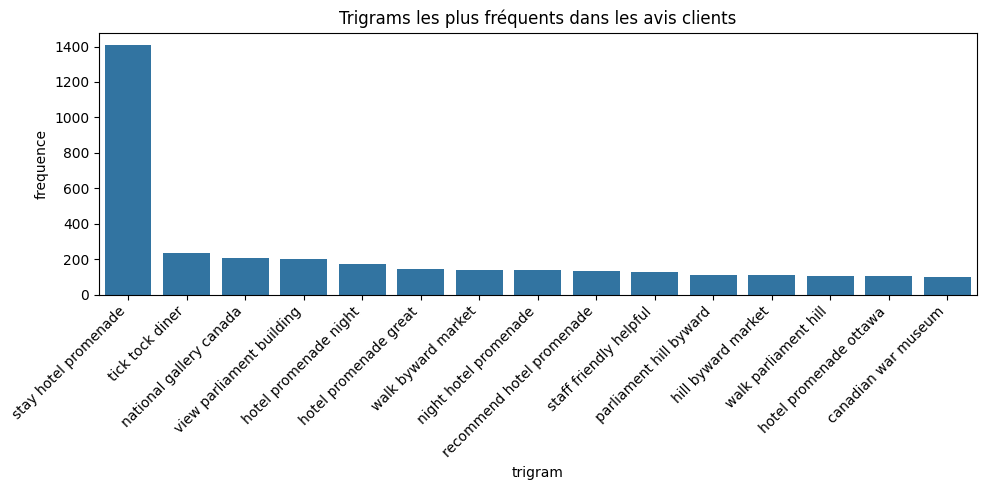

In [ ]:
plt.figure(figsize=(10, 5))
sns.barplot(data=df_tri, x="trigram", y="frequence")
plt.title("Trigrams les plus fréquents dans les avis clients")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

on observe des expressions complètes décrivant plus précisément l’expérience client. On observe notamment des phrases liées à la proximité des attractions touristiques (Byward Market, Parliament Hill, National Gallery, Canadian War Museum), à l’expérience de séjour à l’hôtel, ainsi qu’à la qualité du personnel (staff friendly helpful). Ces résultats confirment l’importance de la localisation, du service et de l’environnement touristique dans la perception globale de l’hôtel par les clients

## Analyse thématique par TF-IDF

Après l’analyse fréquentielle et l’étude des n-grammes, la vectorisation TF-IDF est utilisée afin d’identifier les termes les plus discriminants dans les avis clients.

TF-IDF = (importance du mot dans l’avis) × (rareté du mot dans l’ensemble des avis)

In [ ]:
texts_tfidf = df_filtre["lemmas"].apply(
    lambda toks: " ".join([t for t in toks if t not in stop_extra])
)

In [ ]:
# On reconstruit un texte par avis à partir des lemmes
texts_tfidf = df_filtre["lemmas"].apply(lambda x: " ".join(x))
texts_tfidf.head()

,lemmas
0,chambre confortable décoration démoder petit d...
1,spa proposer traitement signatur exclusif déve...
2,séjour correct justifi pleinement classemer lu...
3,laundry service express save gala dinner follo...
4,exposition collection art contemporain hôtel p...


Vectorisation TF-IDF

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer
import numpy as np
import pandas as pd

tfidf_vectorizer = TfidfVectorizer(
    max_df=0.7,        # ignore termes trop présents partout
    min_df=20,         # ignore termes trop rares
    ngram_range=(1,2)  # mots + expressions
)

X_tfidf = tfidf_vectorizer.fit_transform(texts_tfidf)

feature_names = np.array(tfidf_vectorizer.get_feature_names_out())
mean_tfidf = np.asarray(X_tfidf.mean(axis=0)).ravel()

tfidf_scores = pd.DataFrame({
    "terme": feature_names,
    "score_tfidf": mean_tfidf
}).sort_values(by="score_tfidf", ascending=False)

top_tfidf = tfidf_scores.head(20)
top_tfidf

,terme,score_tfidf
2671,stay,0.043268
2091,promenade,0.037797
1334,hotel promenade,0.037299
1870,ottawa,0.033327
2484,service,0.030104
1139,great,0.029699
2629,staff,0.027041
1107,good,0.026455
1568,location,0.023694
1797,night,0.022449


Mots les plus importants globalement (score moyen TF-IDF)

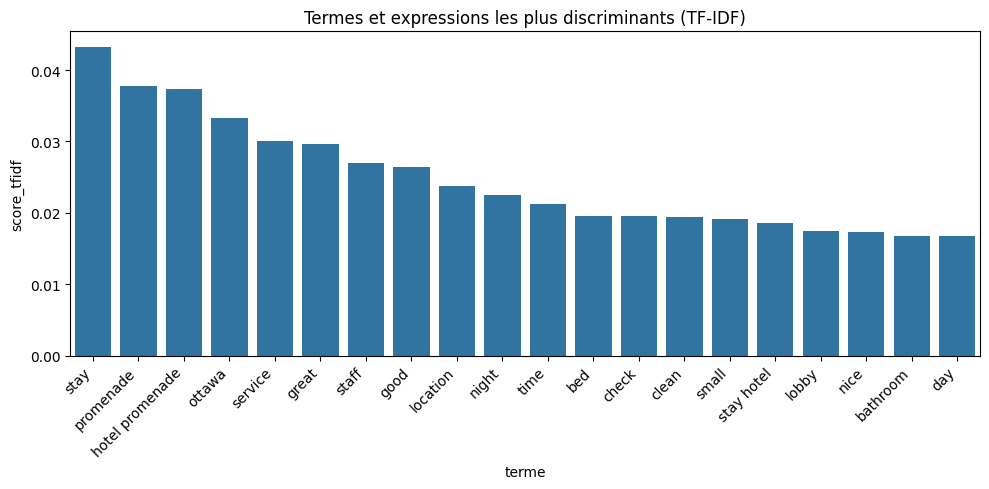

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10,5))
sns.barplot(data=top_tfidf, x="terme", y="score_tfidf")
plt.title("Termes et expressions les plus discriminants (TF-IDF)")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

L’analyse exploratoire des avis clients, combinant fréquences, n-grammes et pondération TF-IDF, met en évidence plusieurs thèmes récurrents dans l’expérience des clients : la qualité du service, la propreté, le confort des chambres, la localisation de l’hôtel et les services de restauration. Ces résultats sont cohérents entre les différentes méthodes d’analyse et confirment que ces dimensions constituent les principaux facteurs influençant la perception globale de l’établissement.

# Résumé des insights exploitables pour la direction

L’analyse des avis clients de l’Hôtel de la Promenade, basée sur des méthodes de traitement du langage naturel (nettoyage du texte, analyse fréquentielle, n-grammes et pondération TF-IDF), met en évidence plusieurs axes majeurs de l’expérience client.

### 1. Qualité du service et du personnel
Les termes et expressions liés au service, ainsi qu’au personnel (par exemple « service », « friendly », « helpful »), apparaissent fréquemment et de manière discriminante dans les avis. Cela indique que l’attitude et l’efficacité du personnel constituent un facteur central dans la satisfaction des clients. Le service est un levier clé de perception positive de l’établissement.

### 2. Propreté et état des chambres
Les thèmes liés à la propreté et aux équipements (par exemple « clean », « bathroom », « bed », « room ») sont très présents. Les clients accordent une grande importance à la propreté et au confort des chambres. Les remarques sur la taille, l’état ou le confort des chambres montrent que ces aspects influencent fortement l’évaluation globale du séjour.

### 3. Confort et équipements
Des termes comme « comfortable », « bed », « floor », « old » ou « small » indiquent que le confort et l’état général des installations sont des sujets récurrents. Cela suggère que des améliorations ciblées sur la literie, l’insonorisation, l’état des chambres ou la modernisation de certains espaces pourraient avoir un impact positif direct sur la satisfaction client.

### 4. Localisation et environnement
La localisation ressort comme un point fort important, avec des références fréquentes à des lieux et points d’intérêt à proximité (par exemple « location », « parliament », « byward market », « walk », « view »). L’accessibilité à pied et la proximité des attractions touristiques constituent un avantage concurrentiel clair pour l’hôtel.

### 5. Restauration et services annexes
Le thème du petit-déjeuner (« breakfast ») apparaît également comme un élément distinctif dans les avis. Cela montre que l’expérience de restauration fait partie intégrante de l’évaluation du séjour et peut être un levier d’amélioration ou de différenciation.

### En conclusion
Les analyses montrent que la satisfaction des clients repose principalement sur quatre piliers : la qualité du service, la propreté et le confort des chambres, la localisation de l’hôtel et certains services spécifiques comme le petit-déjeuner. Ces résultats suggèrent que les priorités stratégiques devraient se concentrer sur le maintien d’un haut niveau de service, l’amélioration continue du confort et de l’état des chambres, ainsi que la mise en valeur de la localisation privilégiée de l’établissement dans la communication et l’expérience client.

#2. Assistant RAG (Réponses Factuelles)

### Objectif
Construire un assistant interne (pour employés) qui répond **strictement** à partir de la documentation de l’hôtel.
Aucune invention : si l’info n’est pas dans la doc, l’assistant le dit.

## Installation et importation des librairie

In [ ]:
!pip -q install pypdf faiss-cpu sentence-transformers rank-bm25 langchain-text-splitters

import os, re
import numpy as np
import pandas as pd

from pypdf import PdfReader
import faiss

from sentence_transformers import SentenceTransformer
from rank_bm25 import BM25Okapi
from langchain_text_splitters import RecursiveCharacterTextSplitter

## Chargement des fichiers

In [ ]:
import os

DOC_DIR = "/content/drive/MyDrive/Projet UA1 IAG"

# Liste brute du dossier
all_files = os.listdir(DOC_DIR)

# On garde seulement PDF/HTML
docs = [f for f in all_files if f.lower().endswith((".pdf"))]

print("Fichiers doc détectés:", len(docs))
for f in docs:
    print("-", f)

Fichiers doc détectés: 7
- Partie 3 - FAQ - Hôtel De la Promenade.pdf
- Processus - Gestion des réservations.pdf
- politiques_hotel_de_la_promenade_document.pdf
- Principes de vie internes.pdf
- Membres du comité SST.pdf
- Hébergement - Critères du service d'entretien ménager dans un hôtel 4 diamants.pdf
- Convention collective - services alimentaires.pdf


## Selection de la documentation

In [ ]:
import os

DOC_DIR = "/content/drive/MyDrive/Projet UA1 IAG"

DOCS = [
    "politiques_hotel_de_la_promenade_document.pdf",
    "Principes de vie internes.pdf",
    "Convention collective - services alimentaires.pdf",
    "Membres du comité SST.pdf",
]

paths = [os.path.join(DOC_DIR, f) for f in DOCS if os.path.exists(os.path.join(DOC_DIR, f))]

print("Docs trouvés:", len(paths))
for p in paths:
    print("-", os.path.basename(p))

Docs trouvés: 4
- politiques_hotel_de_la_promenade_document.pdf
- Principes de vie internes.pdf
- Convention collective - services alimentaires.pdf
- Membres du comité SST.pdf


## Extraction et structuration de la documentation interne

### Objectif
Transformer les documents PDF internes de l’Hôtel de la Promenade en une base de connaissances exploitable par le système RAG.

In [ ]:
import unicodedata
import re

def clean_text_basic(t: str) -> str:
    if not t:
        return ""

    # Normalisation unicode
    t = unicodedata.normalize("NFKC", t)

    # Remplacer espaces insécables
    t = t.replace("\u00A0", " ").replace("\u202F", " ")

    # Normaliser tous les tirets unicode vers "-"
    t = re.sub(r"[\u2010\u2011\u2012\u2013\u2014\u2212]", "-", t)

    # Supprimer caractères nuls + espaces multiples
    t = t.replace("\x00", " ")
    t = re.sub(r"\s+", " ", t).strip()
    return t

def load_pdf(path: str):
    reader = PdfReader(path)
    docs = []
    for i, page in enumerate(reader.pages):
        text = clean_text_basic(page.extract_text() or "")
        if len(text) < 80:  # ignore pages vides/bruit
            continue
        docs.append({
            "text": text,
            "metadata": {
                "source": os.path.basename(path),
                "page": i + 1,
                "type": "pdf"
            }
        })
    return docs

raw_docs = []
for p in paths:
    raw_docs.extend(load_pdf(p))

print("Pages utiles extraites :", len(raw_docs))
print(raw_docs[0]["metadata"])
print(raw_docs[0]["text"][:300])

Pages utiles extraites : 42
{'source': 'politiques_hotel_de_la_promenade_document.pdf', 'page': 1, 'type': 'pdf'}
Manuel Opérationnel & Politiques - Hôtel De la Promenade Localisation : Ottawa, Ontario, Canada Version du document : 3.0 (Mis à jour le 12 janvier 2026) Usage : Interne, Formation du personnel Table des matières 1. Présentation & informations générales 2. Mission, vision et valeurs 3. Coordonnées e



Nous avons obtenu **42 pages utiles extraites** à partir des documents sélectionnés.Les pages trop courtes ou vides ont été automatiquement ignorées  et Chaque page a été transformée en un bloc structuré contenant le texte nettoyé, le nom du document source, le numéro de page et le type de document

Chunking

In [ ]:
splitter = RecursiveCharacterTextSplitter(
    chunk_size=1000,
    chunk_overlap=120,    # overlap
    separators=["\n\n", "\n", ". ", " ", ""]
)

chunks = []
for d in raw_docs:
    for c in splitter.split_text(d["text"]):
        c = clean_text_basic(c)
        if len(c) < 50:
            continue
        chunks.append({
            "text": c,
            "metadata": d["metadata"]
        })

print("Chunks finaux :", len(chunks))
print(chunks[0]["metadata"])
print(chunks[0]["text"][:300])

Chunks finaux : 90
{'source': 'politiques_hotel_de_la_promenade_document.pdf', 'page': 1, 'type': 'pdf'}
Manuel Opérationnel & Politiques - Hôtel De la Promenade Localisation : Ottawa, Ontario, Canada Version du document : 3.0 (Mis à jour le 12 janvier 2026) Usage : Interne, Formation du personnel Table des matières 1. Présentation & informations générales 2. Mission, vision et valeurs 3. Coordonnées e


90 chunks au total

In [ ]:
print("Métadonnées :", chunks[0]["metadata"])
print("\nContenu du chunk :\n")
print(chunks[4]["text"])

Métadonnées : {'source': 'politiques_hotel_de_la_promenade_document.pdf', 'page': 1, 'type': 'pdf'}

Contenu du chunk :

Type de Chambre Etages Capacité max Équipements Tarif (à partir de) Type de Chambre Etages Capacité max Équipements Tarif (à partir de) Chambre Classique 3e - 4e 4 pers. Wi-Fi, Nespresso, produits écologiques 289$ / nuit Chambre Deluxe 3e - 4e 2 pers. Plus d'espace, Nespresso, minibar 314$ / nuit Suite Junior 4e - 5e 2 pers. Salon séparé, coin repas 422$ / nuit Suite Senior 5e 4 pers. King, sofa-lit, cuisinette 575$ / nuit Suite Exécutive 5e 4 pers. King Deluxe, SDB complète, cuisinette 818$ / nuit Équipements standards : Wi-Fi haute vitesse gratuit, machine Nespresso, produits de bain écologiques, peignoirs, coffre-fort, fer & planche à repasser sur demande. Politiques linge & ménage Nettoyage quotidien standard; changement du linge tous les 3 jours sauf demande contraire (programme éco-friendly). Demandes spéciales (lit bébé, lit d'appoint) : à préciser lors de la 

j'ai afficher le chunck 4 afin de voir son contenu

Embeddings

In [ ]:
embed_model = SentenceTransformer("paraphrase-multilingual-MiniLM-L12-v2")

texts = [c["text"] for c in chunks]
emb = embed_model.encode(texts, convert_to_numpy=True, normalize_embeddings=True)

print("Embeddings shape:", emb.shape)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


Embeddings shape: (90, 384)


In [ ]:
dim = emb.shape[1]
index = faiss.IndexFlatIP(dim)  # cosine si embeddings normalisés
index.add(emb)

print("FAISS index size:", index.ntotal)

FAISS index size: 90


## Stratégie de Retrieval Hybride (BM25 + Embeddings)

Afin d'améliorer la pertinence des passages récupérés dans le système RAG, j'ai mis en place une approche hybride combinant **Recherche lexicale (BM25)**, basée sur la correspondance exacte des mots-clés et **Recherche sémantique (embeddings + FAISS)**, basée sur la similarité de sens entre la question et les segments de texte.

Cette stratégie hybride permet :
- d’améliorer la précision des passages récupérés,
- de réduire les risques d’hallucination,
- d’augmenter la robustesse du système face à des questions formulées différemment.


Retrieval top-k

In [ ]:
def retrieve(query: str, k: int = 5):
    q_emb = embed_model.encode([query], convert_to_numpy=True, normalize_embeddings=True)
    scores, ids = index.search(q_emb, k)
    results = []
    for score, idx in zip(scores[0], ids[0]):
        item = chunks[int(idx)]
        results.append({
            "score": float(score),
            "text": item["text"],
            "metadata": item["metadata"]
        })
    return results

test = retrieve("Quelles sont les heures de check-in et check-out ?", k=5)
for r in test:
    print(r["score"], r["metadata"])
    print(r["text"][:180], "\n")

0.5409132242202759 {'source': 'Convention collective - services alimentaires.pdf', 'page': 18, 'type': 'pdf'}
Page 17 a) Tous les efforts seront faits par l’Employeur pour que chaque employé bénéficie d’une période de repos de quarante-huit (48) heures consécutives par semaine. b) Pour les 

0.5270463228225708 {'source': 'Convention collective - services alimentaires.pdf', 'page': 17, 'type': 'pdf'}
Page 16 d) La semaine de travail standard des employés à temps partiel est déterminée selon l'accord conclu entre l'Employeur, le Syndicat et l'employé. L'horaire de base peut être 

0.49024498462677 {'source': 'Convention collective - services alimentaires.pdf', 'page': 17, 'type': 'pdf'}
. e) Lesdits changements peuvent impliquer une variation maximale de 2 heures avant ou après l’horaire d’origine, à moins de l’accord de l’employé. f) L’Employeur ne peut pas exige 

0.48455607891082764 {'source': 'Convention collective - services alimentaires.pdf', 'page': 23, 'type': 'pdf'}
Page 22 d) L

In [ ]:
tokenized_corpus = [t.lower().split() for t in texts]
bm25 = BM25Okapi(tokenized_corpus)

def retrieve_hybrid(query: str, k: int = 8, alpha: float = 0.5):
    # BM25
    bm25_scores = bm25.get_scores(query.lower().split())
    bm25_scores = (bm25_scores - bm25_scores.min()) / (bm25_scores.max() - bm25_scores.min() + 1e-9)

    # Dense
    q_emb = embed_model.encode([query], convert_to_numpy=True, normalize_embeddings=True)
    dense_scores, dense_ids = index.search(q_emb, len(texts))
    dense_scores = dense_scores[0]
    dense_scores = (dense_scores - dense_scores.min()) / (dense_scores.max() - dense_scores.min() + 1e-9)

    # Fusion
    hybrid = alpha * bm25_scores + (1 - alpha) * dense_scores

    top_idx = np.argsort(-hybrid)[:k]
    results = []
    for idx in top_idx:
        results.append({
            "score": float(hybrid[idx]),
            "text": chunks[idx]["text"],
            "metadata": chunks[idx]["metadata"]
        })
    return results

In [ ]:
!pip -q install transformers accelerate bitsandbytes

## Fonction `cuda_cleanup()`

## Objectif
Libérer la mémoire RAM et la mémoire GPU (VRAM) inutilisées afin d’éviter les erreurs de type **CUDA out of memory** et stabiliser l’exécution.

In [ ]:
import gc, torch

def cuda_cleanup():
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
        torch.cuda.ipc_collect()

cuda_cleanup()
print(" VRAM nettoyée")

 VRAM nettoyée


## Quelques intallations et verifications

In [ ]:
!pip -q uninstall -y transformers accelerate
!pip -q install --no-cache-dir -U transformers==4.51.3 accelerate==0.34.2

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.4/10.4 MB 137.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 324.4/324.4 kB 224.1 MB/s eta 0:00:00


In [ ]:
import transformers
print(transformers.__version__)

4.51.3


In [ ]:
!pip -q install --no-cache-dir "bitsandbytes==0.46.1"

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.9/72.9 MB 186.4 MB/s eta 0:00:00


In [ ]:
import bitsandbytes as bnb
print("bnb file:", bnb.__file__)
print("bnb version:", getattr(bnb, "__version__", "unknown"))
print("has functional:", hasattr(bnb, "functional"))

bnb file: /usr/local/lib/python3.12/dist-packages/bitsandbytes/__init__.py
bnb version: 0.46.1
has functional: True


# Chargement du Modèle (Quantification 4-bit sur GPU)

Le modèle **Mistral-7B-Instruct-v0.2** est chargé afin de générer des réponses dans le système RAG.  
Pour optimiser l’utilisation de la mémoire GPU, une quantification 4-bit via bitsandbytes est utilisée, ce qui permet d’exécuter un modèle 7B dans un environnement comme Google Colab.  
Le paramètre **device_map={"": 0}** force le chargement complet du modèle sur le GPU afin d’améliorer la vitesse d’inférence.  
Cette configuration garantit un bon équilibre entre performance, rapidité et consommation mémoire.

In [ ]:
import torch
from transformers import AutoTokenizer, AutoModelForCausalLM, BitsAndBytesConfig

MODEL_ID = "mistralai/Mistral-7B-Instruct-v0.2"

bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_use_double_quant=True,
    bnb_4bit_compute_dtype=torch.float16
)

tokenizer = AutoTokenizer.from_pretrained(MODEL_ID)
if tokenizer.pad_token_id is None:
    tokenizer.pad_token = tokenizer.eos_token


model = AutoModelForCausalLM.from_pretrained(
    MODEL_ID,
    quantization_config=bnb_config,
    device_map={"": 0},     # <-- force 100% GPU
)

model.config.pad_token_id = tokenizer.pad_token_id
print(" Modèle chargé 100% sur GPU")

Loading checkpoint shards:   0%|          | 0/3 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/111 [00:00<?, ?B/s]

 Modèle chargé 100% sur GPU


## Fonction de génération

In [ ]:
import torch, gc

def cuda_cleanup():
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
        torch.cuda.ipc_collect()

def generate_llm(prompt: str, max_new_tokens: int = 120) -> str:

    inputs = tokenizer(
        prompt,
        return_tensors="pt",
        truncation=True,
        max_length=2048
    )
    inputs = {k: v.to(model.device) for k, v in inputs.items()}

    with torch.inference_mode():
        outputs = model.generate(
            **inputs,
            max_new_tokens=max_new_tokens,
            do_sample=False,
            use_cache=False,  #  réduit la VRAM
            eos_token_id=tokenizer.eos_token_id,
            pad_token_id=tokenizer.pad_token_id
        )

    text = tokenizer.decode(outputs[0], skip_special_tokens=True)
    if text.startswith(prompt):
        text = text[len(prompt):].strip()

    cuda_cleanup()
    return text.strip()

## Construction des differents Prompt:
   
   ## Prompt 1 : Zero-Shot

### Objectif
Encadrer le modèle pour répondre uniquement à partir du contexte récupéré, sans exemples préalables, afin d’évaluer sa capacité à suivre strictement les instructions et éviter l’hallucination.

### Règles imposées au modèle :

- Répondre STRICTEMENT à partir du contexte fourni.
- Ne pas utiliser de connaissances externes si l'information n'est pas trouvée
- Réponse concise et professionnelle.


   ## Prompt 2: Few-shot

### Objectif
Guider le modèle en lui montrant des exemples de bonnes réponses factuelles, afin d’améliorer la précision, la structure et la stabilité

### Règles imposées au modèle :

- Répondre uniquement à partir du CONTEXTE.
- Ne pas inventer d’informations.
- Ne pas générer d’autres questions/réponses.
-Réponse professionnelle (1–3 phrases maximum).

   ## Prompt 3: Chain-of-Thought (CoT)

### Objectif
Forcer le modèle à raisonner à partir du contexte avant de donner la réponse finale, afin d’améliorer la précision dans les cas complexes.

### Règles imposées au modèle :

- Analyser le contexte étape par étape.
- Ne pas inventer d’informations.
- Fournir une réponse finale claire et concise.
- Ne pas afficher un raisonnement inutilement long.

### Structure des prompt

Rôle du modèle (assistant interne)
Règles strictes
Contexte (chunks récupérés)
Question
Zone de réponse


In [ ]:
def build_prompt_zero_shot(question: str, retrieved: list[dict]) -> str:
    ctx = "\n\n".join(
        [f"[{r['metadata']['source']} | page {r['metadata']['page']}]\n{r['text']}"
         for r in retrieved]
    )
    return f"""
Tu es un assistant interne pour l'Hôtel de la Promenade.
Tu réponds STRICTEMENT à partir du CONTEXTE.
Règles:
- N'invente rien.
- Si l'information n'est pas explicitement dans le contexte, réponds exactement:
"Information non disponible dans la documentation interne."
- Réponds en français, de façon concise proffessionele et poli.

CONTEXTE:
{ctx}

QUESTION:
{question}

RÉPONSE:
""".strip()


def build_prompt_few_shot(question: str, retrieved: list[dict]) -> str:
    ctx = "\n\n".join(
        [f"[{r['metadata']['source']} | page {r['metadata']['page']}]\n{r['text']}"
         for r in retrieved]
    )
    return f"""
Tu es un assistant interne pour l'Hôtel de la Promenade.
Tu réponds STRICTEMENT à partir du CONTEXTE fourni.

Exemple 1:
Question: Quelle est l'heure du check-out ?
Réponse:
Le check-out est prévu jusqu'à 11h00. (Politiques, p.2)

Exemple 2:
Question: Quels sont les frais du service de valet ?
Réponse:
Le service de valet coûte 38$ par nuit avec entrées et sorties illimitées. (Politiques, p.9)

Règles:
- Ne pas utiliser d'information externe.
- Ne pas inventer.
- Si l'information n'est pas dans le contexte, répondre exactement:
"Information non disponible dans la documentation interne."
- Réponse concise et professionnelle.

Important:
- Ne génère PAS d'autres exemples.
- Ne génère PAS d'autres questions.
- Écris uniquement la réponse finale (1-3 phrases max).

CONTEXTE:
{ctx}

QUESTION:
{question}

RÉPONSE:
""".strip()


def build_prompt_cot(question: str, retrieved: list[dict]) -> str:
    ctx = "\n\n".join(
        [f"[{r['metadata']['source']} | page {r['metadata']['page']}]\n{r['text']}"
         for r in retrieved]
    )
    return f"""
Tu es un assistant interne de l'Hôtel de la Promenade.
Analyse brièvement le CONTEXTE avant de répondre.

Règles:
- Utiliser uniquement le contexte.
- Si absent du contexte, répondre exactement:
"Information non disponible dans la documentation interne."

CONTEXTE:
{ctx}

QUESTION:
{question}

ANALYSE (1-2 phrases max):
RÉPONSE:
""".strip()

## Libère au max la VRAM

In [ ]:
import os, json
import torch
import gc

def cuda_cleanup():

    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
        torch.cuda.ipc_collect()

def load_done_keys(checkpoint_path: str) -> set:
    """Lit un JSONL et retourne l'ensemble des clés déjà traitées."""
    done = set()
    if not checkpoint_path or not os.path.exists(checkpoint_path):
        return done

    with open(checkpoint_path, "r", encoding="utf-8") as f:
        for line in f:
            line = line.strip()
            if not line:
                continue
            try:
                rec = json.loads(line)
                if "key" in rec:
                    done.add(rec["key"])
            except json.JSONDecodeError:
                # ligne corrompue -> on ignore pour ne pas casser
                continue
    return done

def append_jsonl(checkpoint_path: str, record: dict):
    """Ajoute 1 record dans le JSONL (écriture immédiate)."""
    os.makedirs(os.path.dirname(checkpoint_path), exist_ok=True) if os.path.dirname(checkpoint_path) else None
    with open(checkpoint_path, "a", encoding="utf-8") as f:
        f.write(json.dumps(record, ensure_ascii=False) + "\n")
        f.flush()
        os.fsync(f.fileno())

## Fonction ASK

basée sur le système de retrieval hybride et de génération par LLM, avec gestion optionnelle de checkpoint. cette fonction construit une clé unique combinant le mode, le scénario et la question afin d’éviter les doublons et permettre la reprise automatique via un fichier JSONL. Selon le mode choisi (zero, few ou cot) Enfin, elle produit la réponse du modèle, enregistre les métadonnées essentielles dont la meilleure source, affiche un résumé propre et libère la mémoire CUDA.

In [ ]:
def ask(
    question: str,
    mode: str = "few",
    k: int = 5,
    alpha: float = 0.5,
    print_only_answer: bool = True,
    show_top_source: bool = True,
    # --- checkpoint ---
    checkpoint_path: str = None,
    scenario_name: str = None,
    resume: bool = True,
    max_new_tokens: int = 160
):
    """
    mode: 'zero' | 'few' | 'cot'
    Si checkpoint_path est fourni:
      - génère une clé unique (mode|scenario|question)
      - si resume=True, skip si déjà présent
      - sinon calcule, écrit dans JSONL
    """

    # clé unique
    scenario_name = scenario_name or "UNKNOWN_SCENARIO"
    key = f"{mode}||{scenario_name}||{question}"

    # Skip si déjà fait
    if checkpoint_path and resume:
        done = load_done_keys(checkpoint_path)
        if key in done:
            print(f"[SKIP] Déjà généré: {mode} | {scenario_name} | {question}")
            return None

    # Retrieval
    retrieved = retrieve_hybrid(question, k=k, alpha=alpha)

    # Prompt selon mode
    if mode == "zero":
        prompt = build_prompt_zero_shot(question, retrieved)
    elif mode == "few":
        prompt = build_prompt_few_shot(question, retrieved)
    elif mode == "cot":
        prompt = build_prompt_cot(question, retrieved)
    else:
        raise ValueError("mode doit être 'zero', 'few' ou 'cot'")

    #  Génération
    answer = generate_llm(prompt, max_new_tokens=max_new_tokens)

    #  Top1 référence uniquement
    top1 = None
    if retrieved and len(retrieved) > 0:
        r0 = retrieved[0]
        md = r0["metadata"]
        top1 = {
            "source": md.get("source"),
            "page": md.get("page"),
            "score": round(float(r0.get("score", 0.0)), 4)
        }

    #  Construire record JSON
    record = {
        "key": key,
        "mode": mode,
        "scenario": scenario_name,
        "question": question,
        "answer": answer,
        "top1": top1,
        "k": k,
        "alpha": alpha
    }

    # Sauvegarde immédiate
    if checkpoint_path:
        append_jsonl(checkpoint_path, record)

    # Affichage propre (sans chunk)
    print(f"Q: {question}")
    print(f"A: {answer}")

    if show_top_source and top1:
        print(f"(Réf: {top1['source']} | page {top1['page']} | score={top1['score']})")

    print("-" * 90)

    cuda_cleanup()

    return record

## Maintenant testons different types de scenarios internes

In [ ]:
SCENARIOS = {
    "Réservations / Annulation / No-show": [
        "Quelle est la politique d'annulation ?",
        "Quels sont les frais en cas de no-show ?",
        "Les réservations de groupe nécessitent-elles un dépôt ?",
    ],
    "Front Desk (Check-in / Check-out)": [
        "À quelle heure est le check-in ?",
        "À quelle heure est le check-out ?",
        "Quels sont les frais de late check-out ?",
        "Le early check-in est-il possible et à quel coût ?",
    ],
    "Restauration / Bistro / Room service": [
        "Le room service est-il disponible et quels sont les frais ?",
        "Quels sont les délais estimés du room service ?",
        "Y a-t-il des frais de service automatiques pour les groupes ?",
    ],
    "Stationnement / Mobilité": [
        "Quels sont les frais de stationnement ou valet ?",
        "Y a-t-il une navette disponible ?",
    ],
    "Animaux": [
        "Les animaux sont-ils acceptés ?",
        "Quelle est la politique pour les animaux d'assistance ?",
    ],
    "RH / Employés": [
        "Quel est le rabais employé au bistro ?",
        "Quelles sont les règles de code vestimentaire ?",
    ],
    "Sécurité / Urgences": [
        "Quelle est la procédure en cas d'incident ou d'urgence ?",
        "Y a-t-il des consignes d'évacuation ?",
    ],
    "Hors-doc (anti-hallucination)": [
        "Quel est le taux d'occupation moyen annuel de l'hôtel ?",
        "Quel est le chiffre d'affaires du bistro l'an dernier ?",
    ],
}

## Boucle sur modes + scénarios + questions.
 Sauvegarde chaque résultat dans un JSONL avec sauvegarde des questions deja traiter en cas d'interruption



In [ ]:
def run_scenarios_all_modes(
    scenarios,
    modes=("zero", "few", "cot"),
    k=5,
    alpha=0.5,
    checkpoint_path="rag_checkpoint_all_modes.jsonl",
    resume=True,
    print_only_answer=True,
    show_top_source=True,
    max_new_tokens=160
):

    for mode in modes:
        print("\n" + "="*100)
        print(f"MODE: {mode.upper()}")
        print("="*100)

        for scenario_name, questions in scenarios.items():
            print("\n" + "-"*100)
            print(f"SCÉNARIO: {scenario_name}")
            print("-"*100)

            for q in questions:
                try:
                    ask(
                        q,
                        mode=mode,
                        k=k,
                        alpha=alpha,
                        print_only_answer=print_only_answer,
                        show_top_source=show_top_source,
                        checkpoint_path=checkpoint_path,
                        scenario_name=scenario_name,
                        resume=resume,
                        max_new_tokens=max_new_tokens
                    )
                except RuntimeError as e:
                    # Cas typique: CUDA OOM
                    print(f"[ERREUR] {type(e).__name__}: {e}")
                    cuda_cleanup()
                    # stop proprement pour reprendre plus tard
                    return
                except Exception as e:
                    print(f"[ERREUR] {type(e).__name__}: {e}")
                    cuda_cleanup()
                    return

    print("\n Terminé. Checkpoint:", checkpoint_path)

## REPONSES AVEC LA SOURCE AU MEILLEUR SCORE

In [ ]:
results = run_scenarios_all_modes(
    SCENARIOS,
    modes=("zero","few","cot"),
    k=5,
    alpha=0.5,
    checkpoint_path="/content/drive/MyDrive/Projet UA1 IAG/rag_checkpoint.json"
)


MODE: ZERO

----------------------------------------------------------------------------------------------------
SCÉNARIO: Réservations / Annulation / No-show
----------------------------------------------------------------------------------------------------
[SKIP] Déjà généré: zero | Réservations / Annulation / No-show | Quelle est la politique d'annulation ?
[SKIP] Déjà généré: zero | Réservations / Annulation / No-show | Quels sont les frais en cas de no-show ?
[SKIP] Déjà généré: zero | Réservations / Annulation / No-show | Les réservations de groupe nécessitent-elles un dépôt ?

----------------------------------------------------------------------------------------------------
SCÉNARIO: Front Desk (Check-in / Check-out)
----------------------------------------------------------------------------------------------------
[SKIP] Déjà généré: zero | Front Desk (Check-in / Check-out) | À quelle heure est le check-in ?
[SKIP] Déjà généré: zero | Front Desk (Check-in / Check-out) | À 

Lecture du fichier JSON

In [ ]:
import json

file_path = "/content/drive/MyDrive/Projet UA1 IAG/rag_checkpoint.json"

records = []

with open(file_path, "r", encoding="utf-8") as f:
    for line in f:
        records.append(json.loads(line))

print("Nombre d'entrées :", len(records))

Nombre d'entrées : 60


In [ ]:
for r in records:
    print(f"[{r['mode'].upper()}] {r['scenario']}")
    print("Q:", r["question"])
    print("A:", r["answer"])

    if r["top1"]:
        ref = r["top1"]
        print(f"(Réf: {ref['source']} | page {ref['page']} | score={ref['score']})")

    print("-" * 90)

[ZERO] Réservations / Annulation / No-show
Q: Quelle est la politique d'annulation ?
A: Aucun frais pour une annulation plus de 4 heures avant l'heure prévue. Frais de 25 $ facturés à la chambre ou sur la carte de crédit en cas de "No-Show" (non-présentation) pour une réservation confirmée.
(Réf: politiques_hotel_de_la_promenade_document.pdf | page 5 | score=0.893)
------------------------------------------------------------------------------------------
[ZERO] Réservations / Annulation / No-show
Q: Quels sont les frais en cas de no-show ?
A: Des frais de 25 $ sont facturés à la chambre ou sur la carte de crédit en cas de "No-Show" (non-présentation) pour une réservation confirmée.
(Réf: politiques_hotel_de_la_promenade_document.pdf | page 2 | score=0.8871)
------------------------------------------------------------------------------------------
[ZERO] Réservations / Annulation / No-show
Q: Les réservations de groupe nécessitent-elles un dépôt ?
A: Oui, un dépôt de garantie de 10 $ pa

# Analyse Comparative des Modes de Prompting  Testés et Justification – Assistant RAG

## Objectif

L’objectif de cette phase était d’évaluer le comportement du modèle selon trois stratégies de prompting différentes :

- ZERO-SHOT
- FEW-SHOT
- Chain-of-Thought (COT)

Les mêmes scénarios et questions ont été utilisés pour chaque mode afin de comparer la qualité, la précision et la cohérence des réponses générées.



#Mode ZERO-SHOT

## Observations

- Les réponses sont globalement correctes et factuelles.
- Le modèle fournit parfois plus d’informations que nécessaire.
- Certaines réponses combinent plusieurs politiques ou éléments dans une même réponse.
- Le style est moins structuré.

## Interprétation

En mode ZERO-SHOT, le modèle répond sans exemple préalable.  
Il comprend correctement la documentation mais n’est pas guidé dans la forme attendue. Le contenu est fiable, mais parfois trop détaillé ou légèrement dispersé.


#Mode FEW-SHOT

## Observations

- Les réponses sont plus structurées et plus professionnelles.
- Le ton est plus cohérent.
- Les réponses sont concises tout en restant complètes.
- La citation des sources est mieux intégrée.

## Interprétation

Le FEW-SHOT améliore clairement la stabilité et la qualité des réponses.  
Les exemples fournis dans le prompt permettent au modèle de mieux comprendre le format attendu afin d'adopter un ton plus professionnel et d'Éviter les réponses trop longues. Ce mode présente le meilleur équilibre entre précision, clarté et structure.



#Mode Chain-of-Thought (COT)

## Observations

- Les réponses sont plus synthétiques.
- Le modèle va directement à l’essentiel.
- Certaines réponses sont très courtes et très directes.
- Parfois, certains détails secondaires peuvent être omis.

## Interprétation

Le mode COT pousse le modèle à raisonner avant de répondre.  
Cela améliore la clarté et la concision, mais peut parfois entraîner une simplification excessive. Il est efficace pour des réponses rapides et directes, mais moins optimal si une réponse complète est attendue.


#Validation du Système RAG

##Qualité du Retrieval

Les scores de similarité et les pages retournées correspondent aux sections pertinentes des documents et les réponses générées sont cohérentes avec les politiques internes.Cela confirme que :

- Le découpage en chunks est pertinent
- L’index vectoriel fonctionne correctement
- La récupération hybride (BM25 + dense) est efficace


##Anti-hallucination

Les questions hors documentation (ex. taux d’occupation, chiffre d’affaires) ont généré la réponse : "Information non disponible dans la documentation interne."

Cela démontre que :

- Le modèle respecte la contrainte d’utiliser uniquement la base documentaire
- Le système limite efficacement les hallucinations
- Le prompt est correctement structuré


#Comparaison Synthétique des Modes

En ce qui concerne l’exactitude factuelle, les trois approches (Zero-shot, Few-shot et Chain-of-Thought) obtiennent des résultats satisfaisants. Aucune différence majeure n’a été observée sur la justesse des informations fournies.

Au niveau de la structure des réponses, l’approche Zero-shot présente une organisation moyenne, tandis que les approches Few-shot et Chain-of-Thought offrent une structure plus claire et mieux organisée.

Concernant la concision, le Zero-shot reste correct mais parfois un peu moins synthétique. Le Few-shot améliore la clarté tout en restant relativement concis, alors que le Chain-of-Thought se distingue par une formulation très bien structurée et particulièrement efficace dans la synthèse des idées.

En termes de stabilité des réponses, le Few-shot apparaît comme le plus constant et le plus fiable. Le Zero-shot montre une stabilité moyenne, tandis que le Chain-of-Thought reste bon, mais légèrement plus variable selon la formulation du prompt.

Enfin, le risque d’omission d’information est faible pour les approches Zero-shot et Few-shot. En revanche, avec le Chain-of-Thought, le risque d’omission est légèrement plus élevé, probablement en raison de la complexité supplémentaire introduite par le raisonnement détaillé.

#Conclusion Générale

L’assistant RAG développé est fonctionnel et fiable. en effet les tests montrent que :

- Le retrieval est performant
- L’anti-hallucination est efficace
- Le prompting influence fortement la qualité des réponses

Le mode FEW-SHOT apparaît comme le plus adapté pour une utilisation interne par les employés de l’hôtel de la promenade, car il offre le meilleur équilibre entre précision, structure et cohérence.

Ce système peut donc être considéré comme opérationnel pour un déploiement interne contrôlé.

#3. Assistant Fine-tuné (Style & Ton)

**Objectif : Répondre aux questions en imitant le style de réponse spécifique de l'hôtel :** en respectant le contenu de la FAQ

je fait d’abord un **test baseline** (modèle non fine-tuné),
puis on entraîne, puis on **re-teste** sur les mêmes questions pour mesurer le gain.

## Installation des dépendances
cette etape a pour objectif de mettre en place un environnement stable pour mes exécution

In [ ]:
%%capture
import os, importlib.util
!pip install --upgrade -qqq uv
if importlib.util.find_spec("torch") is None or "COLAB_" in "".join(os.environ.keys()):
    try: import numpy, PIL; _numpy = f"numpy=={numpy.__version__}"; _pil = f"pillow=={PIL.__version__}"
    except: _numpy = "numpy"; _pil = "pillow"
    !uv pip install -qqq \
        "torch>=2.8.0" "triton>=3.4.0" {_numpy} {_pil} torchvision bitsandbytes "transformers==4.56.2" \
        "unsloth_zoo[base] @ git+https://github.com/unslothai/unsloth-zoo" \
        "unsloth[base] @ git+https://github.com/unslothai/unsloth" \
        git+https://github.com/triton-lang/triton.git@0add68262ab0a2e33b84524346cb27cbb2787356#subdirectory=python/triton_kernels
elif importlib.util.find_spec("unsloth") is None:
    !uv pip install -qqq unsloth
!uv pip install --upgrade --no-deps transformers==4.56.2 tokenizers trl==0.22.2 unsloth unsloth_zoo

## Charger le modèle de base, création de l'adapteur LoRA et configuration des adaptateurs LoRA avec Unsloth

Chargement du modèle Mistral 7B Instruct en 4-bit, puis ajouter un adaptateur LoRA pour entraîner seulement une petite partie des paramètres



In [ ]:
from unsloth import FastLanguageModel
import torch

model_name = "unsloth/mistral-7b-instruct-v0.3-bnb-4bit"

model, tokenizer = FastLanguageModel.from_pretrained(
    model_name = model_name,
    max_seq_length = 2048,
    dtype = None,
    load_in_4bit = True,
)

# Configurer et appliquer LoRA en une seule étape avec Unsloth
model = FastLanguageModel.get_peft_model(
    model,
    r=16,                              # Rang — capacité des adaptateurs
    lora_alpha=32,                     # Facteur d'échelle (α) — souvent 2×r
    target_modules=[                   # Couches ciblées par LoRA
        "q_proj", "k_proj", "v_proj", "o_proj",   # Couches d'attention
        "gate_proj", "up_proj", "down_proj",       # Couches MLP (Feed-Forward)
    ],
    lora_dropout=0,                    # Unsloth recommande 0 (optimisé en interne)
    bias="none",                       # Pas de biais entraînable
    use_gradient_checkpointing="unsloth",  # Économise 30% de VRAM supplémentaire
    random_state=42,
)

# Afficher le nombre de paramètres entraînables
model.print_trainable_parameters()
# < 1% des paramètres totaux !

🦥 Unsloth: Will patch your computer to enable 2x faster free finetuning.


🦥 Unsloth Zoo will now patch everything to make training faster!


==((====))==  Unsloth 2026.2.1: Fast Mistral patching. Transformers: 4.56.2.
   \\   /|    Tesla T4. Num GPUs = 1. Max memory: 14.563 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.10.0+cu128. CUDA: 7.5. CUDA Toolkit: 12.8. Triton: 3.6.0
\        /    Bfloat16 = FALSE. FA [Xformers = None. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


Unsloth 2026.2.1 patched 32 layers with 32 QKV layers, 32 O layers and 32 MLP layers.


trainable params: 41,943,040 || all params: 7,289,966,592 || trainable%: 0.5754


## Inspecter le Tokenizer et le Chat Template



In [ ]:
messages_demo = [
    {"role": "user", "content": "Salut, est ce que votre etablissement accepte les animaux ?"},
    {"role": "assistant", "content": "Oui, mais seulement les chat et les chiens !"}
]

formatted = tokenizer.apply_chat_template(messages_demo, tokenize=False)
print(formatted)

<s>[INST] Salut, est ce que votre etablissement accepte les animaux ?[/INST] Oui, mais seulement les chat et les chiens !</s>


## Tester le modèle de base AVANT le fine\-tuning

Avant de fine-tuner, il faut établir une **baseline** de comment le modèle se comporte normalement.

On s'attend à des réponses **polies et neutres** (comportement par défaut).


In [ ]:
from transformers import TextStreamer

messages = [{"role": "user", "content": "Quels sont vos horaires de check-in ?"}]

inputs = tokenizer.apply_chat_template(
    messages,
    add_generation_prompt = True,
    return_tensors = "pt",
    return_dict = True,
    reasoning_effort = "low",
).to("cuda")

_ = model.generate(**inputs, max_new_tokens = 1024, streamer = TextStreamer(tokenizer))

<s>[INST] Quels sont vos horaires de check-in 

?[/INST] 

Nos 

horaires 

de 

...

en 

contactant 

notre 

service 

clientèle.</s>


la reaction du modele est normale du fait qu'il ai pas de contexte ainsi que de style de reponse. par consequent il donne une repone generale correct mais qui n'a pas de rapport avec notre hotel

## dataset

Les réponses doivent quand même contenir la **bonne information**. On veut un modèle chaleureux, pas un modèle qui dit n'importe quoi !



In [ ]:
from datasets import Dataset

# Dataset FAQ — chaque exemple est une paire instruction/réponse
dataset_faq =[
  {
    "instruction": "À quelle heure puis-je m'enregistrer à l'hôtel ?",
    "output": "Bienvenue à l'Hôtel De la Promenade ! Notre enregistrement standard débute à 15h00, moment où votre refuge urbain vous attend, fraîchement préparé. Vous arrivez plus tôt et souhaitez déposer vos valises ? Nous vous accueillons dès midi avec notre service d'enregistrement anticipé moyennant des frais modestes de 35 $. Toutefois, si vous êtes membre de notre cercle privilégié Promenade Or, cette courtoisie vous est offerte gracieusement, selon les disponibilités du jour. Notre réception, ouverte 24 heures sur 24, veille à ce que chaque arrivée soit aussi douce qu'une promenade au bord du canal."
  },
  {
    "instruction": "Pouvez-vous me dire À quelle heure est-ce que je peux m'enregistrer chez vous  ?",
    "output": "Avec plaisir. Bienvenue à l'Hôtel De la Promenade ! Notre enregistrement standard débute à 15h00, moment où votre refuge urbain vous attend, fraîchement préparé. Vous arrivez plus tôt et souhaitez déposer vos valises ? Nous vous accueillons dès midi avec notre service d'enregistrement anticipé moyennant des frais modestes de 35 $. Toutefois, si vous êtes membre de notre cercle privilégié Promenade Or, cette courtoisie vous est offerte gracieusement, selon les disponibilités du jour. Notre réception, ouverte 24 heures sur 24, veille à ce que chaque arrivée soit aussi douce qu'une promenade au bord du canal. Nous restons à votre disposition."
  },
  {
    "instruction": "Puis-je amener mon chien à l'hôtel ?",
    "output": "Mais certainement ! Chez nous, les compagnons à quatre pattes font partie de la famille. Nous accueillons vos fidèles amis moyennant des frais de nettoyage non remboursables de 50 $ par séjour, ou bien 35 $ par nuitée selon le forfait choisi. Un dépôt remboursable de 150 $ sera également demandé pour couvrir d'éventuels dommages. Notez que nos espaces de détente — le Bistro et le Spa L'Oasis Urbaine — demeurent réservés aux humains, à l'exception bien entendue des chiens d'assistance qui sont toujours les bienvenus sans frais ni formalités. Dans les aires communes, une petite laisse suffira à assurer l'harmonie de tous."
  },
  {
    "instruction": "J’aimerais savoir puis-je amener mon chien chez vous ?",
    "output": "Bien sûr. Mais certainement ! Chez nous, les compagnons à quatre pattes font partie de la famille. Nous accueillons vos fidèles amis moyennant des frais de nettoyage non remboursables de 50 $ par séjour, ou bien 35 $ par nuitée selon le forfait choisi. Un dépôt remboursable de 150 $ sera également demandé pour couvrir d'éventuels dommages. Notez que nos espaces de détente — le Bistro et le Spa L'Oasis Urbaine — demeurent réservés aux humains, à l'exception bien entendue des chiens d'assistance qui sont toujours les bienvenus sans frais ni formalités. Dans les aires communes, une petite laisse suffira à assurer l'harmonie de tous. Au plaisir de vous accueillir à l’Hôtel De la Promenade."
  },
  {
    "instruction": "Est-ce que votre hôtel offre le Wi-Fi gratuit ?",
    "output": "Absolument ! Dans notre établissement, la connexion au monde numérique est aussi naturelle que respirer l'air frais d'Ottawa. Toutes nos chambres — de la Classique à l'Exécutive — bénéficient d'un accès Wi-Fi haute vitesse sans frais supplémentaires. Parce qu'un séjour raffiné, c'est aussi rester relié à ce qui compte, que ce soit pour le travail ou le plaisir."
  },
  {
    "instruction": "Pouvez-vous me dire est-ce que votre hôtel offre le wi-fi gratuit ?",
    "output": "Ravi de vous aider. Absolument ! Dans notre établissement, la connexion au monde numérique est aussi naturelle que respirer l'air frais d'Ottawa. Toutes nos chambres — de la Classique à l'Exécutive — bénéficient d'un accès Wi-Fi haute vitesse sans frais supplémentaires. Parce qu'un séjour raffiné, c'est aussi rester relié à ce qui compte, que ce soit pour le travail ou le plaisir. N’hésitez pas si vous souhaitez une précision."
  },
  {
    "instruction": "Quelles sont vos politiques d'annulation ?",
    "output": "Nous comprenons que les plans peuvent évoluer comme les saisons. Pour nos tarifs flexibles, vous pouvez annuler sans pénalité jusqu'à 24 heures avant 15h00 le jour de votre arrivée prévue — une liberté que nous chérissons autant que vous. En revanche, nos tarifs prépayés non remboursables, comme leur nom l'indique avec élégance, ne permettent aucune modification une fois la réservation confirmée. Nos forfaits spéciaux (Romantique, Famille) requièrent un préavis de 48 heures, sauf indication contraire précisée lors de votre réservation. Et si le destin vous empêche de nous rejoindre sans préavis, nous facturerons avec regret la première nuit, taxes comprises. Notre réception demeure à votre écoute pour toute question à ce sujet."
  },
  {
    "instruction": "Auriez-vous l’info : quelles sont vos politiques d'annulation ?",
    "output": "Merci pour votre question. Nous comprenons que les plans peuvent évoluer comme les saisons. Pour nos tarifs flexibles, vous pouvez annuler sans pénalité jusqu'à 24 heures avant 15h00 le jour de votre arrivée prévue — une liberté que nous chérissons autant que vous. En revanche, nos tarifs prépayés non remboursables, comme leur nom l'indique avec élégance, ne permettent aucune modification une fois la réservation confirmée. Nos forfaits spéciaux (Romantique, Famille) requièrent un préavis de 48 heures, sauf indication contraire précisée lors de votre réservation. Et si le destin vous empêche de nous rejoindre sans préavis, nous facturerons avec regret la première nuit, taxes comprises. Notre réception demeure à votre écoute pour toute question à ce sujet. N’hésitez pas si vous souhaitez une précision."
  },
  {
    "instruction": "Le petit-déjeuner est-il inclus dans le prix de la chambre ?",
    "output": "L'inclusion du petit-déjeuner dépend du forfait que vous avez sélectionné lors de votre réservation. Notre forfait « Couette et Café », par exemple, comprend un délicieux déjeuner santé au Bistro De la Promenade — une façon exquise de commencer la journée. Si votre réservation ne comporte pas cette prestation, pas d'inquiétude ! Notre Bistro vous accueille tous les matins de 6h30 à 11h00 en semaine, et dès 7h00 la fin de semaine, avec des créations artisanales qui raviront vos papilles. Du croissant au beurre façonné maison (4 $) à notre assiette de fruits frais de saison (14 $), chaque bouchée célèbre les saveurs locales et l'art de bien commencer la journée."
  },
  {
    "instruction": "Pouvez-vous me dire Le petit-déjeuner est-il inclus dans le prix de la chambre  ?",
    "output": "Avec plaisir. L'inclusion du petit-déjeuner dépend du forfait que vous avez sélectionné lors de votre réservation. Notre forfait « Couette et Café », par exemple, comprend un délicieux déjeuner santé au Bistro De la Promenade — une façon exquise de commencer la journée. Si votre réservation ne comporte pas cette prestation, pas d'inquiétude ! Notre Bistro vous accueille tous les matins de 6h30 à 11h00 en semaine, et dès 7h00 la fin de semaine, avec des créations artisanales qui raviront vos papilles. Du croissant au beurre façonné maison (4 $) à notre assiette de fruits frais de saison (14 $), chaque bouchée célèbre les saveurs locales et l'art de bien commencer la journée. Au plaisir de vous accueillir à l’Hôtel De la Promenade."
  },
  {
    "instruction": "À quelle heure dois-je libérer ma chambre ?",
    "output": "Le départ standard s'effectue à 11h00, heure à laquelle votre chambre retrouve son éclat pour accueillir les prochains visiteurs. Vous souhaitez prolonger votre séjour jusqu'à 14h00 ? Nous proposons un départ tardif moyennant 50 $, vous offrant ainsi quelques heures supplémentaires de tranquillité. Au-delà de cette heure, le tarif d'une nuitée complète s'appliquera. Comme toujours, notre équipe à la réception se fera un plaisir d'accommoder vos besoins dans la mesure du possible."
  },
  {
    "instruction": "J’aimerais savoir À quelle heure dois-je libérer ma chambre  ?",
    "output": "Ravi de vous aider. Le départ standard s'effectue à 11h00, heure à laquelle votre chambre retrouve son éclat pour accueillir les prochains visiteurs. Vous souhaitez prolonger votre séjour jusqu'à 14h00 ? Nous proposons un départ tardif moyennant 50 $, vous offrant ainsi quelques heures supplémentaires de tranquillité. Au-delà de cette heure, le tarif d'une nuitée complète s'appliquera. Comme toujours, notre équipe à la réception se fera un plaisir d'accommoder vos besoins dans la mesure du possible."
  },
  {
    "instruction": "Offrez-vous un service de stationnement ?",
    "output": "Certainement ! Nous proposons deux formules pour votre véhicule. Notre service de voiturier attentionné, au tarif de 38 $ par nuit, vous permet des entrées et sorties illimitées — une danse parfaite entre liberté et commodité. Si vous préférez stationner vous-même, notre stationnement souterrain sécurisé est disponible à 28 $ la nuit (veuillez noter que la hauteur maximale est de 2,1 mètres). Et pour nos visiteurs soucieux de l'environnement, des bornes de recharge pour véhicules électriques vous attendent gratuitement aux niveaux P1 et P2, selon la disponibilité. Parce qu'un avenir durable commence dans notre garage."
  },
  {
    "instruction": "Pouvez-vous me dire Offrez-vous un service de stationnement  ?",
    "output": "Ravi de vous aider. Certainement ! Nous proposons deux formules pour votre véhicule. Notre service de voiturier attentionné, au tarif de 38 $ par nuit, vous permet des entrées et sorties illimitées — une danse parfaite entre liberté et commodité. Si vous préférez stationner vous-même, notre stationnement souterrain sécurisé est disponible à 28 $ la nuit (veuillez noter que la hauteur maximale est de 2,1 mètres). Et pour nos visiteurs soucieux de l'environnement, des bornes de recharge pour véhicules électriques vous attendent gratuitement aux niveaux P1 et P2, selon la disponibilité. Parce qu'un avenir durable commence dans notre garage. Au plaisir de vous accueillir à l’Hôtel De la Promenade."
  },
  {
    "instruction": "Avez-vous un restaurant sur place ?",
    "output": "Mais oui, et quel restaurant ! Le Bistro De la Promenade est notre joyau culinaire, un café-bistro artisanal où les cafés de spécialité rencontrent les produits locaux dans une symphonie de saveurs. Nos baristas, formés selon les standards internationaux, vous accueillent du lundi au vendredi de 6h30 à 22h00, et les fins de semaine de 7h00 à 23h00. Le petit-déjeuner se déploie jusqu'à 11h00, le lunch de 11h30 à 14h00, et le souper de 17h00 à 22h00. La fin de semaine, notre brunch légendaire s'étend de 8h00 à 14h00 — un moment de pure gourmandise. L'ambiance ? Décontractée le jour, feutrée en soirée. Du sandwich Déjeuner (12 $) au Burger De la Promenade avec son confit d'oignon (18 $), chaque plat raconte une histoire de terroir et de passion. Et si vous préférez savourer tout cela dans l'intimité de votre chambre, notre service aux chambres est disponible aux mêmes heures, moyennant des frais de livraison de 5 $ (gratuits pour nos suites Exécutives)."
  },
  {
    "instruction": "Auriez-vous l’info : Avez-vous un restaurant sur place  ?",
    "output": "Merci pour votre question. Mais oui, et quel restaurant ! Le Bistro De la Promenade est notre joyau culinaire, un café-bistro artisanal où les cafés de spécialité rencontrent les produits locaux dans une symphonie de saveurs. Nos baristas, formés selon les standards internationaux, vous accueillent du lundi au vendredi de 6h30 à 22h00, et les fins de semaine de 7h00 à 23h00. Le petit-déjeuner se déploie jusqu'à 11h00, le lunch de 11h30 à 14h00, et le souper de 17h00 à 22h00. La fin de semaine, notre brunch légendaire s'étend de 8h00 à 14h00 — un moment de pure gourmandise. L'ambiance ? Décontractée le jour, feutrée en soirée. Du sandwich Déjeuner (12 $) au Burger De la Promenade avec son confit d'oignon (18 $), chaque plat raconte une histoire de terroir et de passion. Et si vous préférez savourer tout cela dans l'intimité de votre chambre, notre service aux chambres est disponible aux mêmes heures, moyennant des frais de livraison de 5 $ (gratuits pour nos suites Exécutives). Au plaisir de vous accueillir à l’Hôtel De la Promenade."
  },
  {
    "instruction": "Acceptez-vous les animaux d'assistance ?",
    "output": "Sans la moindre hésitation ! Les animaux d'assistance sont accueillis chaleureusement et sans aucun frais à l'Hôtel De la Promenade. Aucune identification n'est requise si votre compagnon est clairement reconnaissable comme animal d'assistance. Ces fidèles alliés peuvent vous accompagner partout dans l'hôtel, y compris au Bistro et au Spa L'Oasis Urbaine. Leur présence à vos côtés est un droit que nous respectons avec la plus grande dignité."
  },
  {
    "instruction": "Est-ce que vous pouvez préciser Acceptez-vous les animaux d'assistance  ?",
    "output": "Ravi de vous aider. Sans la moindre hésitation ! Les animaux d'assistance sont accueillis chaleureusement et sans aucun frais à l'Hôtel De la Promenade. Aucune identification n'est requise si votre compagnon est clairement reconnaissable comme animal d'assistance. Ces fidèles alliés peuvent vous accompagner partout dans l'hôtel, y compris au Bistro et au Spa L'Oasis Urbaine. Leur présence à vos côtés est un droit que nous respectons avec la plus grande dignité. Nous restons à votre disposition."
  },
  {
    "instruction": "Puis-je fumer dans ma chambre ?",
    "output": "Hélas, non. Pour le bien-être de tous nos visiteurs et la pureté de l'air que nous partageons, toute forme de fumée — tabac ou cannabis — est strictement interdite à l'intérieur de l'établissement. Des espaces fumeurs extérieurs désignés vous attendent toutefois pour ces moments de pause. En cas de violation de cette politique, des frais de nettoyage de 250 $ seront facturés, auxquels s'ajouteront les coûts réels si nécessaires. Nous comptons sur votre compréhension pour préserver l'atmosphère raffinée de notre hôtel."
  },
  {
    "instruction": "Pouvez-vous me dire puis-je fumer dans ma chambre ?",
    "output": "Bien sûr. Hélas, non. Pour le bien-être de tous nos visiteurs et la pureté de l'air que nous partageons, toute forme de fumée — tabac ou cannabis — est strictement interdite à l'intérieur de l'établissement. Des espaces fumeurs extérieurs désignés vous attendent toutefois pour ces moments de pause. En cas de violation de cette politique, des frais de nettoyage de 250 $ seront facturés, auxquels s'ajouteront les coûts réels si nécessaires. Nous comptons sur votre compréhension pour préserver l'atmosphère raffinée de notre hôtel. Bonne journée !"
  },
  {
    "instruction": "Offrez-vous des forfaits spéciaux pour les couples ?",
    "output": "Ah, l'amour ! Notre forfait « Week-end Romantique » (code AMOUR) est conçu précisément pour ces moments où deux cœurs ne font qu'un. Au prix fixe de 1 200 $ (plus taxes), ce forfait vous offre un hébergement en Suite Junior, une bouteille de bulles accompagnée de chocolats fins déposée avant votre arrivée, et un repas gastronomique pour deux personnes — un menu dégustation qui éveillera tous vos sens. Notre conciergerie se fera également un plaisir de vous suggérer des activités intimes : excursions en bateau sur le canal, visites privées de musées, tours guidés des quartiers historiques d'Ottawa. Parce que chaque grande histoire d'amour mérite un décor à sa hauteur."
  },
  {
    "instruction": "Quelle est Offrez-vous des forfaits spéciaux pour les couples  ?",
    "output": "Voici l’information selon notre FAQ. Ah, l'amour ! Notre forfait « Week-end Romantique » (code AMOUR) est conçu précisément pour ces moments où deux cœurs ne font qu'un. Au prix fixe de 1 200 $ (plus taxes), ce forfait vous offre un hébergement en Suite Junior, une bouteille de bulles accompagnée de chocolats fins déposée avant votre arrivée, et un repas gastronomique pour deux personnes — un menu dégustation qui éveillera tous vos sens. Notre conciergerie se fera également un plaisir de vous suggérer des activités intimes : excursions en bateau sur le canal, visites privées de musées, tours guidés des quartiers historiques d'Ottawa. Parce que chaque grande histoire d'amour mérite un décor à sa hauteur. Au plaisir de vous accueillir à l’Hôtel De la Promenade."
  },
  {
    "instruction": "Avez-vous un spa dans l'hôtel ?",
    "output": "Oui, et pas n'importe quel spa ! L'Oasis Urbaine, situé au deuxième étage, est notre sanctuaire dédié à la détente et au renouveau. Ouvert du mardi au dimanche de 10h00 à 20h00 (fermé le lundi pour entretien), ce havre de paix propose des massages suédois (135 $ pour 60 minutes), des massages thérapeutiques (190 $ pour 90 minutes), et des soins du visage Éclat (150 $ pour 60 minutes). L'accès à nos bains thermaux coûte 45 $, mais il vous est offert gracieusement si vous réservez un soin d'une heure ou plus. Veuillez noter que l'âge minimum est de 16 ans (13-15 ans avec un parent ou tuteur et formulaire signé). Nous vous recommandons d'arriver 10 à 15 minutes avant votre rendez-vous pour vous immerger pleinement dans l'expérience. Les annulations doivent être effectuées 24 heures à l'avance pour éviter des frais."
  },
  {
    "instruction": "J’aimerais savoir Avez-vous un spa dans l'hôtel  ?",
    "output": "Voici l’information selon notre FAQ. Oui, et pas n'importe quel spa ! L'Oasis Urbaine, situé au deuxième étage, est notre sanctuaire dédié à la détente et au renouveau. Ouvert du mardi au dimanche de 10h00 à 20h00 (fermé le lundi pour entretien), ce havre de paix propose des massages suédois (135 $ pour 60 minutes), des massages thérapeutiques (190 $ pour 90 minutes), et des soins du visage Éclat (150 $ pour 60 minutes). L'accès à nos bains thermaux coûte 45 $, mais il vous est offert gracieusement si vous réservez un soin d'une heure ou plus. Veuillez noter que l'âge minimum est de 16 ans (13-15 ans avec un parent ou tuteur et formulaire signé). Nous vous recommandons d'arriver 10 à 15 minutes avant votre rendez-vous pour vous immerger pleinement dans l'expérience. Les annulations doivent être effectuées 24 heures à l'avance pour éviter des frais. N’hésitez pas si vous souhaitez une précision."
  },
  {
    "instruction": "Proposez-vous des salles pour réunions ou événements ?",
    "output": "Absolument ! Notre Centre d'affaires et nos espaces événementiels sont pensés pour transformer vos rencontres professionnelles en succès mémorables. La Salle Bourgeois accueille jusqu'à 12 personnes autour d'une table ovale (400 $ la demi-journée) — idéale pour ces réunions de direction où chaque voix compte. La Salle Racine peut contenir 40 personnes en configuration école ou 60 en théâtre (850 $ la journée), parfaite pour formations et présentations. Et pour vos grands événements, la Salle Poirier peut accueillir jusqu'à 200 personnes (2 500 $ la journée) — banquets, congrès, célébrations. Projecteur, écran, microphone et sonorisation de base sont inclus. Pour des besoins techniques particuliers, nous demandons un préavis de 7 jours. Notre équipe Congrès & Événements vous accompagne à chaque étape."
  },
  {
    "instruction": "Pouvez-vous me dire Proposez-vous des salles pour réunions ou événements  ?",
    "output": "Merci pour votre question. Absolument ! Notre Centre d'affaires et nos espaces événementiels sont pensés pour transformer vos rencontres professionnelles en succès mémorables. La Salle Bourgeois accueille jusqu'à 12 personnes autour d'une table ovale (400 $ la demi-journée) — idéale pour ces réunions de direction où chaque voix compte. La Salle Racine peut contenir 40 personnes en configuration école ou 60 en théâtre (850 $ la journée), parfaite pour formations et présentations. Et pour vos grands événements, la Salle Poirier peut accueillir jusqu'à 200 personnes (2 500 $ la journée) — banquets, congrès, célébrations. Projecteur, écran, microphone et sonorisation de base sont inclus. Pour des besoins techniques particuliers, nous demandons un préavis de 7 jours. Notre équipe Congrès & Événements vous accompagne à chaque étape. N’hésitez pas si vous souhaitez une précision."
  },
  {
    "instruction": "Quelle est votre politique concernant le bruit et les heures calmes ?",
    "output": "Le repos de nos visiteurs est sacré. Nous demandons donc à chacun de respecter les heures calmes, de 22h00 à 7h00, période durant laquelle le silence devient notre plus belle mélodie. Tout comportement perturbateur ou non-respect de cette politique peut entraîner des amendes, voire une expulsion sans remboursement. Car ici, chaque nuit mérite d'être paisible comme une promenade sous les étoiles."
  },
  {
    "instruction": "Quelle est quelle est votre politique concernant le bruit et les heures calmes ?",
    "output": "Voici l’information selon notre FAQ. Le repos de nos visiteurs est sacré. Nous demandons donc à chacun de respecter les heures calmes, de 22h00 à 7h00, période durant laquelle le silence devient notre plus belle mélodie. Tout comportement perturbateur ou non-respect de cette politique peut entraîner des amendes, voire une expulsion sans remboursement. Car ici, chaque nuit mérite d'être paisible comme une promenade sous les étoiles."
  },
  {
    "instruction": "Puis-je apporter ma propre bouteille de vin au restaurant ?",
    "output": "Mais bien sûr ! Notre politique de droit de bouchon vous permet d'apporter votre propre bouteille de vin au Bistro De la Promenade. Des frais de débouchonnage de 25 $ par bouteille de 750 ml s'appliquent, avec un maximum d'une bouteille par table. Petite précision élégante : le vin que vous apportez ne doit pas figurer sur notre carte actuelle. Parce que partager un bon vin, c'est aussi partager un moment d'authenticité."
  },
  {
    "instruction": "Quelle est puis-je apporter ma propre bouteille de vin au restaurant ?",
    "output": "Avec plaisir. Mais bien sûr ! Notre politique de droit de bouchon vous permet d'apporter votre propre bouteille de vin au Bistro De la Promenade. Des frais de débouchonnage de 25 $ par bouteille de 750 ml s'appliquent, avec un maximum d'une bouteille par table. Petite précision élégante : le vin que vous apportez ne doit pas figurer sur notre carte actuelle. Parce que partager un bon vin, c'est aussi partager un moment d'authenticité. Bonne journée !"
  },
  {
    "instruction": "Avez-vous des options pour les personnes ayant des restrictions alimentaires ?",
    "output": "Naturellement ! Au Bistro De la Promenade, nous honorons chaque régime avec la même attention. Options végétariennes (VG), végétaliennes (VGL), sans gluten (SG) et sans lactose sont disponibles sur simple demande. Toutefois — et ceci est crucial — nous vous prions d'informer votre serveur de toute allergie alimentaire avant de commander. Bien que notre cuisine applique un protocole anti-contamination rigoureux, nous manipulons des noix, fruits de mer et blé. Votre sécurité est notre priorité, mais elle commence par votre communication. L'hôtel ne peut être tenu responsable en cas de réaction si l'allergie n'a pas été déclarée au préalable."
  },
  {
    "instruction": "Auriez-vous l’info : Avez-vous des options pour les personnes ayant des restrictions alimentaires  ?",
    "output": "Avec plaisir. Naturellement ! Au Bistro De la Promenade, nous honorons chaque régime avec la même attention. Options végétariennes (VG), végétaliennes (VGL), sans gluten (SG) et sans lactose sont disponibles sur simple demande. Toutefois — et ceci est crucial — nous vous prions d'informer votre serveur de toute allergie alimentaire avant de commander. Bien que notre cuisine applique un protocole anti-contamination rigoureux, nous manipulons des noix, fruits de mer et blé. Votre sécurité est notre priorité, mais elle commence par votre communication. L'hôtel ne peut être tenu responsable en cas de réaction si l'allergie n'a pas été déclarée au préalable. Bonne journée !"
  },
  {
    "instruction": "Offrez-vous un service de navette vers l'aéroport ?",
    "output": "Oui, nous offrons un service de navette vers l'aéroport sur réservation. Les horaires varient selon la demande, c'est pourquoi nous vous recommandons de réserver à l'avance auprès de notre conciergerie (extension 500). Parce qu'un voyage réussi commence et se termine sans tracas, nous veillons à ce que votre trajet soit aussi fluide que votre séjour."
  },
  {
    "instruction": "Pouvez-vous me dire Offrez-vous un service de navette vers l'aéroport  ?",
    "output": "Ravi de vous aider. Oui, nous offrons un service de navette vers l'aéroport sur réservation. Les horaires varient selon la demande, c'est pourquoi nous vous recommandons de réserver à l'avance auprès de notre conciergerie (extension 500). Parce qu'un voyage réussi commence et se termine sans tracas, nous veillons à ce que votre trajet soit aussi fluide que votre séjour. Nous restons à votre disposition."
  },
  {
    "instruction": "Y a-t-il un centre de conditionnement physique dans l'hôtel ?",
    "output": "Tout à fait ! Notre centre de remise en forme est inclus dans votre séjour et accessible à tous nos clients. L'équipement moderne vous attend pour maintenir votre routine d'entraînement, même loin de chez vous. Parce qu'un corps en mouvement et un esprit apaisé vont de pair. Les détails d'accès vous seront communiqués à la réception lors de votre enregistrement."
  },
  {
    "instruction": "Auriez-vous l’info : Y a-t-il un centre de conditionnement physique dans l'hôtel  ?",
    "output": "Voici l’information selon notre FAQ. Tout à fait ! Notre centre de remise en forme est inclus dans votre séjour et accessible à tous nos clients. L'équipement moderne vous attend pour maintenir votre routine d'entraînement, même loin de chez vous. Parce qu'un corps en mouvement et un esprit apaisé vont de pair. Les détails d'accès vous seront communiqués à la réception lors de votre enregistrement."
  },
  {
    "instruction": "Proposez-vous des forfaits respectueux de l'environnement ?",
    "output": "Ah, voilà une question qui nous tient à cœur ! Notre forfait « Vélo-route Verte » (code ECO-VERT) incarne notre engagement envers la durabilité. Ce forfait comprend l'utilisation exclusive de produits de nettoyage écologiques, des draps en fibres naturelles, et une gestion responsable du linge (changement des serviettes uniquement sur demande). Nos chambres sont équipées d'ampoules à faible consommation et de systèmes de climatisation écoénergétiques. Au petit-déjeuner, vous savourerez des produits locaux et de saison dans des contenants réutilisables ou compostables — zéro plastique à usage unique. Et cerise sur le gâteau vert : accès prioritaire à notre flotte de vélos pour explorer Ottawa de manière douce et silencieuse. Parce que chaque petit geste compte pour préserver la beauté de notre planète."
  },
  {
    "instruction": "J’aimerais savoir Proposez-vous des forfaits respectueux de l'environnement  ?",
    "output": "Avec plaisir. Ah, voilà une question qui nous tient à cœur ! Notre forfait « Vélo-route Verte » (code ECO-VERT) incarne notre engagement envers la durabilité. Ce forfait comprend l'utilisation exclusive de produits de nettoyage écologiques, des draps en fibres naturelles, et une gestion responsable du linge (changement des serviettes uniquement sur demande). Nos chambres sont équipées d'ampoules à faible consommation et de systèmes de climatisation écoénergétiques. Au petit-déjeuner, vous savourerez des produits locaux et de saison dans des contenants réutilisables ou compostables — zéro plastique à usage unique. Et cerise sur le gâteau vert : accès prioritaire à notre flotte de vélos pour explorer Ottawa de manière douce et silencieuse. Parce que chaque petit geste compte pour préserver la beauté de notre planète. N’hésitez pas si vous souhaitez une précision."
  },
  {
    "instruction": "Quel type de café servez-vous au Bistro ?",
    "output": "Notre café est une célébration quotidienne de l'artisanat. Au Bistro De la Promenade, nous torréfions notre propre café, une sélection de grains de première qualité transformés avec passion par nos baristas formés selon les standards internationaux. Notre café filtre maison est servi à volonté sur place pour 3,50 $ (ajout de lait d'avoine pour 0,75 $), tandis que notre café glacé aux fruits de la passion — une création signature — vous transporte en territoire inconnu pour 6,50 $. Chaque tasse est une promenade sensorielle, du grain à la dernière goutte."
  },
  {
    "instruction": "J’aimerais savoir Quel type de café servez-vous au Bistro  ?",
    "output": "Voici l’information selon notre FAQ. Notre café est une célébration quotidienne de l'artisanat. Au Bistro De la Promenade, nous torréfions notre propre café, une sélection de grains de première qualité transformés avec passion par nos baristas formés selon les standards internationaux. Notre café filtre maison est servi à volonté sur place pour 3,50 $ (ajout de lait d'avoine pour 0,75 $), tandis que notre café glacé aux fruits de la passion — une création signature — vous transporte en territoire inconnu pour 6,50 $. Chaque tasse est une promenade sensorielle, du grain à la dernière goutte. N’hésitez pas si vous souhaitez une précision."
  },
  {
    "instruction": "Puis-je réserver une table pour un grand groupe au restaurant ?",
    "output": "Pour les groupes de 6 personnes et plus, nous rendons la réservation obligatoire — et ce, 24 heures à l'avance, afin de vous assurer une expérience impeccable. Pour les rassemblements de 10 personnes ou plus les vendredis et samedis soirs, un dépôt de garantie de 10 $ par personne peut être demandé. À noter également : pour les tables de 8 personnes et plus, une seule facture sera émise (pas de factures séparées), et des frais de service de 15 % sont automatiquement ajoutés avant taxes. Si vous devez annuler, faites-le au moins 4 heures avant l'heure prévue pour éviter des frais. Un « No-Show » (non- présentation sans annulation) entraîne des frais de 25 $ facturés à votre chambre ou carte de crédit. Pour les groupes plus petits (1 à 5 personnes), aucune réservation n'est nécessaire pour le petit-déjeuner et le lunch — premier arrivé, premier servi ! Toutefois, nous recommandons de réserver pour le souper."
  },
  {
    "instruction": "J’aimerais savoir puis-je réserver une table pour un grand groupe au restaurant ?",
    "output": "Avec plaisir. Pour les groupes de 6 personnes et plus, nous rendons la réservation obligatoire — et ce, 24 heures à l'avance, afin de vous assurer une expérience impeccable. Pour les rassemblements de 10 personnes ou plus les vendredis et samedis soirs, un dépôt de garantie de 10 $ par personne peut être demandé. À noter également : pour les tables de 8 personnes et plus, une seule facture sera émise (pas de factures séparées), et des frais de service de 15 % sont automatiquement ajoutés avant taxes. Si vous devez annuler, faites-le au moins 4 heures avant l'heure prévue pour éviter des frais. Un « No-Show » (non- présentation sans annulation) entraîne des frais de 25 $ facturés à votre chambre ou carte de crédit. Pour les groupes plus petits (1 à 5 personnes), aucune réservation n'est nécessaire pour le petit-déjeuner et le lunch — premier arrivé, premier servi ! Toutefois, nous recommandons de réserver pour le souper. Bonne journée !"
  },
  {
    "instruction": "Avez-vous des chambres adaptées pour les familles ?",
    "output": "Absolument ! Nos Suites Senior et Exécutives sont particulièrement adaptées aux familles, pouvant accueillir jusqu'à 4 personnes avec un lit King et un sofa-lit, ainsi qu'une cuisinette pour plus de commodité. De plus, notre forfait « Escapade en Famille » (code FAMILLE) offre une priorité de réservation pour les chambres connectées ou à plusieurs lits, selon disponibilité. Ce forfait inclut également un guide d'activités pour tous les âges et des recommandations de restaurants familiaux à Ottawa. Lits de bébé et lits d'appoint sont disponibles sur demande lors de la réservation. Parce que les souvenirs de famille se construisent dans le confort et la joie."
  },
  {
    "instruction": "Quelle est Avez-vous des chambres adaptées pour les familles  ?",
    "output": "Merci pour votre question. Absolument ! Nos Suites Senior et Exécutives sont particulièrement adaptées aux familles, pouvant accueillir jusqu'à 4 personnes avec un lit King et un sofa-lit, ainsi qu'une cuisinette pour plus de commodité. De plus, notre forfait « Escapade en Famille » (code FAMILLE) offre une priorité de réservation pour les chambres connectées ou à plusieurs lits, selon disponibilité. Ce forfait inclut également un guide d'activités pour tous les âges et des recommandations de restaurants familiaux à Ottawa. Lits de bébé et lits d'appoint sont disponibles sur demande lors de la réservation. Parce que les souvenirs de famille se construisent dans le confort et la joie. Nous restons à votre disposition."
  },
  {
    "instruction": "Combien coûte le service aux chambres ?",
    "output": "Notre service aux chambres est disponible aux mêmes heures que le Bistro — une extension de notre hospitalité jusqu'à votre porte. Des frais de livraison fixes de 5 $ par commande s'appliquent, sauf pour nos Suites Exécutives où ce service vous est offert gracieusement. Le délai d'attente estimé est de 30 à 45 minutes. Après la fermeture de la cuisine, un menu de nuit (sandwichs froids et salades) est disponible via la réception jusqu'à 2h00 du matin. Si vous commandez de l'alcool, une pièce d'identité valide vous sera demandée lors de la livraison. Parce que le confort, c'est aussi savourer un repas en robe de chambre."
  },
  {
    "instruction": "J’aimerais savoir Combien coûte le service aux chambres  ?",
    "output": "Voici l’information selon notre FAQ. Notre service aux chambres est disponible aux mêmes heures que le Bistro — une extension de notre hospitalité jusqu'à votre porte. Des frais de livraison fixes de 5 $ par commande s'appliquent, sauf pour nos Suites Exécutives où ce service vous est offert gracieusement. Le délai d'attente estimé est de 30 à 45 minutes. Après la fermeture de la cuisine, un menu de nuit (sandwichs froids et salades) est disponible via la réception jusqu'à 2h00 du matin. Si vous commandez de l'alcool, une pièce d'identité valide vous sera demandée lors de la livraison. Parce que le confort, c'est aussi savourer un repas en robe de chambre. Nous restons à votre disposition."
  },
  {
    "instruction": "L'hôtel offre-t-il des services de conciergerie ?",
    "output": "Mais certainement ! Notre équipe de conciergerie, joignable à l'extension 500, est votre clé pour déverrouiller les trésors d'Ottawa. Réservations de restaurants, billets de spectacles, recommandations d'activités, organisation de transport — nos experts locaux sont à votre service pour transformer votre séjour en une expérience sur mesure. Ils connaissent la ville comme leur poche et la partagent avec la générosité d'un ami. N'hésitez jamais à faire appel à eux."
  },
  {
    "instruction": "J’aimerais savoir L'hôtel offre-t-il des services de conciergerie  ?",
    "output": "Voici l’information selon notre FAQ. Mais certainement ! Notre équipe de conciergerie, joignable à l'extension 500, est votre clé pour déverrouiller les trésors d'Ottawa. Réservations de restaurants, billets de spectacles, recommandations d'activités, organisation de transport — nos experts locaux sont à votre service pour transformer votre séjour en une expérience sur mesure. Ils connaissent la ville comme leur poche et la partagent avec la générosité d'un ami. N'hésitez jamais à faire appel à eux. N’hésitez pas si vous souhaitez une précision."
  },
  {
    "instruction": "Quelle est votre politique en cas d'objets perdus ?",
    "output": "Les objets trouvés sont scellés dans un sac transparent, étiquetés avec soin (date, lieu, nom de l'employé qui l'a découvert), puis conservés pendant 90 jours. Les cartes de crédit sont immédiatement remises au superviseur pour une gestion sécurisée. Les denrées périssables sont malheureusement jetées le jour même. Si vous croyez avoir oublié quelque chose, contactez notre réception sans tarder — nous ferons tout notre possible pour retrouver votre bien et vous le retourner. Chaque objet raconte une histoire, et nous les traitons avec le respect qu'ils méritent."
  },
  {
    "instruction": "Auriez-vous l’info : quelle est votre politique en cas d'objets perdus ?",
    "output": "Bien sûr. Les objets trouvés sont scellés dans un sac transparent, étiquetés avec soin (date, lieu, nom de l'employé qui l'a découvert), puis conservés pendant 90 jours. Les cartes de crédit sont immédiatement remises au superviseur pour une gestion sécurisée. Les denrées périssables sont malheureusement jetées le jour même. Si vous croyez avoir oublié quelque chose, contactez notre réception sans tarder — nous ferons tout notre possible pour retrouver votre bien et vous le retourner. Chaque objet raconte une histoire, et nous les traitons avec le respect qu'ils méritent."
  },
  {
    "instruction": "Puis-je organiser un mariage ou un événement privé à l'hôtel ?",
    "output": "Mais quelle merveilleuse idée ! Notre Salle Poirier, avec sa capacité allant jusqu'à 200 personnes, se prête magnifiquement aux banquets, mariages et célébrations. Notre équipe Congrès & Événements travaillera avec vous pour créer un contrat sur mesure précisant les nombres d'invités, les menus, l'équipement audiovisuel, les assurances et les politiques d'annulation. Nous proposons des menus de groupe avec 2 à 3 options d'entrées, plats et desserts, incluant des alternatives végétariennes et sans allergènes. L'organisateur est responsable des permis nécessaires (alcool, musique) et peut devoir fournir une attestation d'assurance. Pour les privatisations du Bistro, des frais de service de 18 % et des frais d'administration de 2 % s'appliquent. Chaque détail compte, et nous sommes là pour que votre journée soit inoubliable."
  },
  {
    "instruction": "J’aimerais savoir puis-je organiser un mariage ou un événement privé chez vous ?",
    "output": "Bien sûr. Mais quelle merveilleuse idée ! Notre Salle Poirier, avec sa capacité allant jusqu'à 200 personnes, se prête magnifiquement aux banquets, mariages et célébrations. Notre équipe Congrès & Événements travaillera avec vous pour créer un contrat sur mesure précisant les nombres d'invités, les menus, l'équipement audiovisuel, les assurances et les politiques d'annulation. Nous proposons des menus de groupe avec 2 à 3 options d'entrées, plats et desserts, incluant des alternatives végétariennes et sans allergènes. L'organisateur est responsable des permis nécessaires (alcool, musique) et peut devoir fournir une attestation d'assurance. Pour les privatisations du Bistro, des frais de service de 18 % et des frais d'administration de 2 % s'appliquent. Chaque détail compte, et nous sommes là pour que votre journée soit inoubliable. Bonne journée !"
  },
  {
    "instruction": "Avez-vous des bornes de recharge pour véhicules électriques ?",
    "output": "Oui, et gratuitement ! Nos bornes de recharge pour véhicules électriques sont installées aux niveaux P1 et P2 de notre stationnement souterrain. Elles sont offertes sans frais à nos clients, selon la disponibilité. Un petit geste pour votre budget, un grand geste pour l'environnement. C'est notre façon de dire merci à ceux qui choisissent une mobilité plus verte."
  },
  {
    "instruction": "Est-ce que vous pouvez préciser Avez-vous des bornes de recharge pour véhicules électriques  ?",
    "output": "Voici l’information selon notre FAQ. Oui, et gratuitement ! Nos bornes de recharge pour véhicules électriques sont installées aux niveaux P1 et P2 de notre stationnement souterrain. Elles sont offertes sans frais à nos clients, selon la disponibilité. Un petit geste pour votre budget, un grand geste pour l'environnement. C'est notre façon de dire merci à ceux qui choisissent une mobilité plus verte."
  },
  {
    "instruction": "Offrez-vous un service de location ou de prêt de vélos ?",
    "output": "Absolument ! Notre service de prêt et location de vélos est disponible de 8h00 à 18h00, sur réservation. C'est l'occasion parfaite de découvrir Ottawa à votre rythme, en longeant le canal Rideau ou en explorant les quartiers charmants de la capitale. Les clients du forfait « Vélo-route Verte » bénéficient d'un accès prioritaire. Parce qu'une promenade à vélo, c'est une promenade de liberté."
  },
  {
    "instruction": "J’aimerais savoir Offrez-vous un service de location ou de prêt de vélos  ?",
    "output": "Voici l’information selon notre FAQ. Absolument ! Notre service de prêt et location de vélos est disponible de 8h00 à 18h00, sur réservation. C'est l'occasion parfaite de découvrir Ottawa à votre rythme, en longeant le canal Rideau ou en explorant les quartiers charmants de la capitale. Les clients du forfait « Vélo-route Verte » bénéficient d'un accès prioritaire. Parce qu'une promenade à vélo, c'est une promenade de liberté. N’hésitez pas si vous souhaitez une précision."
  },
  {
    "instruction": "Comment puis-je signaler un problème dans ma chambre ?",
    "output": "Pour tout problème — fuite, panne, souci technique — notre système de ticketing interne assure une intervention rapide. En cas d'urgence (fuite importante, panne électrique), notre équipe de maintenance intervient 24h/7j. Composez simplement l'extension 410 depuis votre chambre, ou contactez la réception au 0. Nous traitons chaque problème avec sérieux et célérité, car votre confort est notre mission première."
  },
  {
    "instruction": "J’aimerais savoir comment est-ce que je peux signaler un problème dans ma chambre ?",
    "output": "Avec plaisir. Pour tout problème — fuite, panne, souci technique — notre système de ticketing interne assure une intervention rapide. En cas d'urgence (fuite importante, panne électrique), notre équipe de maintenance intervient 24h/7j. Composez simplement l'extension 410 depuis votre chambre, ou contactez la réception au 0. Nous traitons chaque problème avec sérieux et célérité, car votre confort est notre mission première. Nous restons à votre disposition."
  },
  {
    "instruction": "L'hôtel est-il accessible aux personnes à mobilité réduite ?",
    "output": "L'Hôtel De la Promenade s'engage envers l'inclusion et le respect de tous. Nous vous invitons à contacter notre réception au +1 (613) 123-4567 ou par courriel à info@delapromenade.ca pour discuter de vos besoins spécifiques en matière d'accessibilité. Notre équipe se fera un plaisir de vous fournir toutes les informations nécessaires et de préparer votre séjour en conséquence. Parce que chaque visiteur mérite un séjour sans barrières."
  },
  {
    "instruction": "Est-ce que vous pouvez préciser L'hôtel est-il accessible aux personnes à mobilité réduite  ?",
    "output": "Voici l’information selon notre FAQ. L'Hôtel De la Promenade s'engage envers l'inclusion et le respect de tous. Nous vous invitons à contacter notre réception au +1 (613) 123-4567 ou par courriel à info@delapromenade.ca pour discuter de vos besoins spécifiques en matière d'accessibilité. Notre équipe se fera un plaisir de vous fournir toutes les informations nécessaires et de préparer votre séjour en conséquence. Parce que chaque visiteur mérite un séjour sans barrières. N’hésitez pas si vous souhaitez une précision."
  }
]

#convertr en dataset Hugging Face
dataset = Dataset.from_list(dataset_faq)

## Formater le dataset avec le Chat Template

On doit convertir nos paires instruction/output au format que Mistral attend, avec les **tokens spéciaux** corrects afin que le modèle apprenne le style de réponse attendu sans ambiguïté.

On ajoute aussi un **system prompt** pour renforcer le comportement chaleureux.



In [ ]:
def format_chat(example):
    """Formate un exemple au format chat template de Mistral."""
    messages = [
        {"role": "user", "content": example["instruction"]},
        {"role": "assistant", "content": example["output"]},
    ]
    formatted = tokenizer.apply_chat_template(messages, tokenize=False, add_generation_prompt = False)
    return {"text": formatted}

# Appliquer le formatage à tout le dataset
dataset = dataset.map(format_chat)

dataset_split = dataset.train_test_split(test_size=0.1, seed=42)
train_dataset = dataset_split["train"]
eval_dataset = dataset_split["test"]

# Vérifier un exemple formaté
print(dataset[0]["text"])

Map:   0%|          | 0/60 [00:00<?, ? examples/s]

<s>[INST] À quelle heure puis-je m'enregistrer à l'hôtel ?[/INST] Bienvenue à l'Hôtel De la Promenade ! Notre enregistrement standard débute à 15h00, moment où votre refuge urbain vous attend, fraîchement préparé. Vous arrivez plus tôt et souhaitez déposer vos valises ? Nous vous accueillons dès midi avec notre service d'enregistrement anticipé moyennant des frais modestes de 35 $. Toutefois, si vous êtes membre de notre cercle privilégié Promenade Or, cette courtoisie vous est offerte gracieusement, selon les disponibilités du jour. Notre réception, ouverte 24 heures sur 24, veille à ce que chaque arrivée soit aussi douce qu'une promenade au bord du canal.</s>


## Configurer les arguments d'entraînement et lancement d'entrainement

- **Epochs = 5** : Nombre de passages sur les données

- **Batch size = 2** avec **gradient accumulation = 4** → Batch effectif = 8

- **Learning rate = 2e-4** : Typique pour LoRA (10-100× plus bas que le pre-training)

- **Warmup = 10 steps** : Montée progressive du learning rate

- **fp16** : Mixed precision pour économiser la VRAM


In [ ]:
from transformers import TrainingArguments

training_args = TrainingArguments(
    output_dir="./results-chaleureux",           # Dossier de sauvegarde
    num_train_epochs=5,                          # nombre de passages sur les données
    per_device_train_batch_size=2,               # Petit batch — VRAM limitée
    gradient_accumulation_steps=4,               # Batch effectif = 2 × 4 = 8
    learning_rate=2e-4,                          # Learning rate typique pour LoRA
    warmup_steps=10,                             # Montée progressive du LR
    logging_steps=5,                             # Logger la loss toutes les 5 steps
    save_strategy="epoch",                       # Sauvegarder à chaque epoch
    fp16=not torch.cuda.is_bf16_supported(),     # Mixed precision (fp16 ou bf16)
    bf16=torch.cuda.is_bf16_supported(),         # bf16 si supporté (meilleur)
    optim="adamw_8bit",                          # Optimiseur 8-bit (économise VRAM)
    report_to="none",                            # Pas de logging externe (wandb, etc.)
    seed=42,

)

In [ ]:
from trl import SFTTrainer

# Créer le trainer
trainer = SFTTrainer(
    model=model,
    tokenizer=tokenizer,
    train_dataset=train_dataset,
    eval_dataset=eval_dataset,
    args=training_args,
    max_seq_length=2048,                  # Longueur max des séquences
)

result = trainer.train()

# Résumé
print(f"Loss finale : {result.training_loss:.4f}")
print(f"Durée : {result.metrics['train_runtime']:.0f} secondes")

Unsloth: Tokenizing ["text"] (num_proc=6):   0%|          | 0/54 [00:00<?, ? examples/s]

Unsloth: Tokenizing ["text"] (num_proc=6):   0%|          | 0/6 [00:00<?, ? examples/s]

==((====))==  Unsloth - 2x faster free finetuning | Num GPUs used = 1
   \\   /|    Num examples = 54 | Num Epochs = 5 | Total steps = 35
O^O/ \_/ \    Batch size per device = 2 | Gradient accumulation steps = 4
\        /    Data Parallel GPUs = 1 | Total batch size (2 x 4 x 1) = 8
 "-____-"     Trainable parameters = 41,943,040 of 7,289,966,592 (0.58% trained)


Step,Training Loss


Loss finale : 0.8375
Durée : 197 secondes


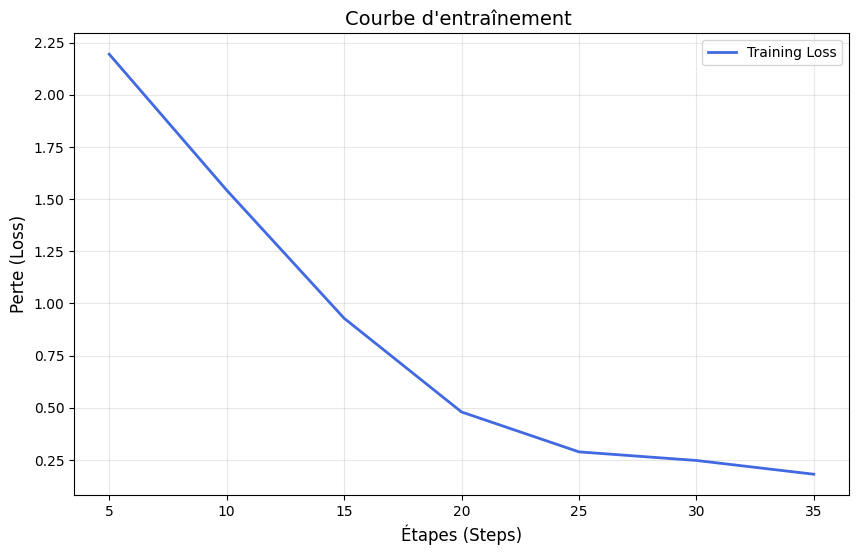

In [ ]:
import matplotlib.pyplot as plt

# Extraire les logs de l'entraînement
history = trainer.state.log_history

# Filtrer les données pour récupérer la loss d'entraînement
train_loss = [log["loss"] for log in history if "loss" in log]
steps = [log["step"] for log in history if "loss" in log]

# Création du graphique
plt.figure(figsize=(10, 6))
plt.plot(steps, train_loss, label="Training Loss", color="royalblue", lw=2)


plt.title("Courbe d'entraînement ", fontsize=14)
plt.xlabel("Étapes (Steps)", fontsize=12)
plt.ylabel("Perte (Loss)", fontsize=12)
plt.legend()
plt.grid(alpha=0.3)
plt.show()

## Analyse de la courbe de perte

La courbe de perte montre une diminution régulière tout au long de l’entraînement, ce qui indique que le modèle apprend efficacement à reproduire le format et le style attendus à partir de la FAQ.

Au début, la perte est élevée (environ 2.2 autour de l’étape 5) puis baisse rapidement jusqu’à environ 0.9 vers l’étape 15. Cette chute rapide est du au faite que le modèle s’adapte aux patterns dominants du dataset.

Ensuite, entre les étapes 15 et 25, la perte continue de baisser mais de façon moins abrupte. Cette phase  montre que le modèle ajuste des détails plus fins plutôt que d’apprendre uniquement la structure globale.

Enfin, entre les étapes 25 et 35, la courbe s’aplatit progressivement et converge vers une zone stable

la courbe indique un entraînement stable montrant l'adaptation du modèle au dataset et a appris le style de réponse, avec une convergence progressive en fin d’entraînement.

## Tester le modèle fine\-tuné \(exemples in\-distribution\)

Testons le modèle sur des questions \*\*similaires\*\* à celles du dataset d'entraînement.

On s'attend à des réponses **du style de l'hotel**



In [ ]:
from unsloth import FastModel

# Passer en mode inférence
FastModel.for_inference(model)

messages = [{"role": "user", "content": "Bonjour, j'arrive tard ce soir, jusqu'à quelle heure puis-je récupérer mes clés ?"}]

inputs = tokenizer.apply_chat_template(
    messages,
    add_generation_prompt = True,
    return_tensors = "pt",
    return_dict = True,
    reasoning_effort = "low",
).to("cuda")

_ = model.generate(**inputs, max_new_tokens = 1024, streamer = TextStreamer(tokenizer))

<s>[INST] Bonjour, j'arrive tard ce soir, jusqu'à quelle heure puis-je récupérer mes clés 

?[/INST] 

Bonjour 

! 

Bienvenue 

...

Nous 

restons 

à 

votre 

disposition.</s>


## Analyse de la réponse après fine-tuning
# **IMPORTANT**

La réponse montre clairement que le modèle a **appris le ton Hôtel De la Promenade** : accueil chaleureux (Bonjour ! Bienvenue…), vocabulaire soigné (raffiné, détendu) et une conclusion orientée service (Nous restons à votre disposition). Sur le plan style, c’est cohérent avec l’objectif du fine-tuning.

Par contre, il y a **deux risques importants** côté exactitude et conformité à la FAQ :

 **Information hors-FAQ**  
jusqu’à 22h00 + extension 400 : ces détails ne sont pas explicitement dans la FAQ, alors le modèle est en train de **compléter** avec des éléments inventés, ce qui peut etre qualifier de manque de pricision sur le information deja fournie. Cela peut etre aussi du du fait que nous avons ajouter les donnees

Le fine-tuning a bien transféré **le style rédactionnel** (forme, ton, vocabulaire). mais Il n’a pas garanti la **fidélité stricte** aux informations de la FAQ. cependant, Répondre aux questions en imitant le style de réponse spécifique de l'hôtel le modèle peut apprendre à ajouter des information.

### Amélioration
On pourrait resoudre ce probleme avec un prompt mais dans ce cas nous limiterons le modele au cas ou il ya des question qui ne sont pas contenus dans la Faq(nous ne disposons pas de toutes les questions possible que l'on peut poser a un hotel) ou autrement,

Pour les **exemples ajoutés**, il faut imposer une règle d’écriture plus trict comme :
- **Interdire** toute donnée non présente dans la FAQ (heures exactes, numéros, montants, extensions).
- Utiliser une formulation safe si l’info n’est pas disponible :  
  *“Cette information n’est pas précisée dans la FAQ. Je vous invite à contacter la réception pour confirmer.”*

Enfin, dans l’instruction/consigne utilisée pour générer les ajouts, renforcer explicitement :
- “Réponds uniquement à partir de la FAQ. Si l’info n’est pas dans la FAQ, dis-le clairement.”

## Tester la généralisation \(exemples out\-of\-distribution\)

cette etape me permettra de savoir est-ce que le modèle est chaleureux même sur des questions qu'il n'a **jamais vues** ?



In [ ]:
messages = [{"role": "user", "content": "Je viens fêter mon anniversaire de mariage chez vous, avez-vous un petit conseil pour rendre ce séjour spécial ?"}]

inputs = tokenizer.apply_chat_template(
    messages,
    add_generation_prompt = True,
    return_tensors = "pt",
    return_dict = True,
    reasoning_effort = "low",
).to("cuda")

_ = model.generate(**inputs, max_new_tokens = 1024, streamer = TextStreamer(tokenizer))

<s>[INST] Je viens fêter mon anniversaire de mariage chez vous, avez-vous un petit conseil pour rendre ce séjour spécial 

?[/INST] 

Ah, 

les 

moments 

...

un 

décor 

à 

sa 

hauteur.</s>


In [ ]:
messages = [{"role": "user", "content": "Je voyage avec mon petit garçon de 4 ans qui est très fatigué. Est-ce qu'il y a un coin calme ou une activité douce pour lui en attendant que notre chambre soit prête ?"}]

inputs = tokenizer.apply_chat_template(
    messages,
    add_generation_prompt = True,
    return_tensors = "pt",
    return_dict = True,
    reasoning_effort = "low",
).to("cuda")

_ = model.generate(**inputs, max_new_tokens = 1024, streamer = TextStreamer(tokenizer))

<s>[INST] Je voyage avec mon petit garçon de 4 ans qui est très fatigué. Est-ce qu'il y a un coin calme ou une activité douce pour lui en attendant que notre chambre soit prête 

?[/INST] 

Avec 

plaisir. 

Oui, 

...

le 

monde 

redevienne 

notre 

rêve.</s>


In [ ]:
messages = [{"role": "user", "content": "Comment appelle-ton le petit du chat?"}]

inputs = tokenizer.apply_chat_template(
    messages,
    add_generation_prompt = True,
    return_tensors = "pt",
    return_dict = True,
    reasoning_effort = "low",
).to("cuda")

_ = model.generate(**inputs, max_new_tokens = 1024, streamer = TextStreamer(tokenizer))

<s>[INST] Comment appelle-ton le petit du 

chat?[/INST] 

Le 

petit 

du 

...

ronde 

qui 

est 

notre 

café.</s>


In [ ]:
messages = [{"role": "user", "content": "quelle est la capitale du Burkina Faso?"}]

inputs = tokenizer.apply_chat_template(
    messages,
    add_generation_prompt = True,
    return_tensors = "pt",
    return_dict = True,
    reasoning_effort = "low",
).to("cuda")

_ = model.generate(**inputs, max_new_tokens = 1024, streamer = TextStreamer(tokenizer))

<s>[INST] quelle est la capitale du Burkina 

Faso?[/INST] 

La 

capitale 

du 

...

milliers 

de 

visiteurs 

chaque 

année.</s>


les reponses montrent que le modele reste chaleureux malgre les information non contenu dans la FAQ ce qui indique que le modele a bien appris sur la maniere de repondre de l'hotel. Par ailleur, comme je le disais dans la partie precedante, le modele ajoute de l'information lorsque l'infos n'est pas contenue dans la Faq tout en respectant le ton ce que nous jugeons correct.

## Comparaison côte à côte — Avant vs Après le fine\-tuning



In [ ]:
from unsloth import FastLanguageModel

messages_finetuned = [{"role": "user", "content": "Quels sont vos horaires de check-in ?"}]
inputs_finetuned = tokenizer.apply_chat_template(
    messages_finetuned,
    add_generation_prompt = True,
    return_tensors = "pt",
    return_dict = True,
    reasoning_effort = "low",
).to("cuda")

print("--- Modèle Fine-tuné ---")
_ = model.generate(**inputs_finetuned, max_new_tokens = 1024, streamer = TextStreamer(tokenizer))


--- Modèle Fine-tuné ---


<s>[INST] Quels sont vos horaires de check-in 

?[/INST] 

Notre 

processus 

...

en 

dehors 

des 

heures 

normales.</s>


In [ ]:
base_model_for_comparison, _ = FastLanguageModel.from_pretrained(
    model_name = "unsloth/mistral-7b-instruct-v0.3-bnb-4bit",
    dtype = None,
    max_seq_length = 1024,
    load_in_4bit = True,
)


messages_base = [{"role": "user", "content": "Quels sont vos horaires de check-in ?"}]
inputs_base = tokenizer.apply_chat_template(
    messages_base,
    add_generation_prompt = True,
    return_tensors = "pt",
    return_dict = True,
    reasoning_effort = "low",
).to("cuda")

print("\n--- Modèle de Base ---")
_ = base_model_for_comparison.generate(**inputs_base, max_new_tokens = 1024, streamer = TextStreamer(tokenizer))

==((====))==  Unsloth 2026.2.1: Fast Mistral patching. Transformers: 4.56.2.
   \\   /|    Tesla T4. Num GPUs = 1. Max memory: 14.563 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.10.0+cu128. CUDA: 7.5. CUDA Toolkit: 12.8. Triton: 3.6.0
\        /    Bfloat16 = FALSE. FA [Xformers = None. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!



--- Modèle de Base ---
<s>[INST] Quels sont vos horaires de check-in 

?[/INST] 

Nos 

horaires 

...

en 

contactant 

notre 

service 

clientèle.</s>


## Comparaison

le modèle de base répond de façon générique , alors que le modèle fine-tuné adopte une voix “Hôtel De la Promenade” beaucoup plus scénarisée et orientée accueil.

Modèle de base : ton neutre, réponse base ssur un logique universelle (passe-partout)
	•	Ton : impersonnel, administratif (veuillez consulter, service clientèle).
	•	Style : standard, prudent, mais non contextualisé (il ne parle pas comme l’hôtel).
	•	Contenu : évite de donner une heure et il renvoie vers le site / contact.
pas utile pour un client qui attend une info immédiate.

Modèle fine-tuné : ton premium, narratif, hospitalité
	•	Ton : chaleureux, premium (refuge urbain, fraîchement préparé, cercle privilégié).
	•	Style : phrase longue, imagée, avec mise en scène et formules de politesse, on sent une signature de marque.
	•	Contenu : donne des détails concrets (15h, early check-in à midi + 35$, gratuit pour membres), et ajoute un passage réception de nuit.
Beaucoup plus “hôtel” dans la forme, et plus actionnable.

Point important (qualité / conformité)
	•	Le fine-tuning a clairement appris le ton et la manière de répondre mais il faut surveiller la fidélité à la FAQ. Si l'objectif etait  un assistant strict, il faudrait empêcher ce type d’extension.